# Day 1 — ESS 배터리 수명 예측 EDA

초기 100사이클로 `cycle_life`를 예측하기 위한 데이터 품질 감사, 다섯 가지 필수 EDA 질문, feature 결정 및 Day 2 모델 전략을 재현합니다.

## 분석 원칙

- MATLAB v7.3 파일을 HDF5로 배치별 순차 접근합니다.
- 수명 분석은 `cycle_life`가 있는 셀만 사용하고 결측 target을 기록 길이로 대체하지 않습니다.
- 초기 summary feature는 실제 cycle 2~100에서 계산합니다.
- `ΔQ(V)`는 실제 cycle 10과 100의 `Qdlin` 차이입니다.
- 전체 열화곡선과 knee point는 설명용이며 Day 2 입력에서 제외합니다.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULT_DIR = PROJECT_ROOT / 'results' / 'day1'
FIGURE_DIR = PROJECT_ROOT / 'figures' / 'day1'
PROJECT_ROOT

PosixPath('/Users/lsh/ess-battery-health')

## 전체 파이프라인 실행

아래 셀은 원본 3개 배치를 다시 읽고 모든 CSV·그래프·보고서를 갱신합니다.

In [2]:
from src.day1_analysis import run_analysis
manifest = run_analysis(PROJECT_ROOT)
manifest

[추출] Batch 1: 2017-05-12_batchdata_updated_struct_errorcorrect.mat


[추출] Batch 2: 2018-02-20_batchdata_updated_struct_errorcorrect.mat


[추출] Batch 3: 2018-04-12_batchdata_updated_struct_errorcorrect.mat


{
  "random_seed": 42,
  "font": "Noto Sans KR",
  "raw_cell_count": 139,
  "labeled_cell_count": 129,
  "batch_files": {
    "Batch 1": "2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "Batch 2": "2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "Batch 3": "2018-04-12_batchdata_updated_struct_errorcorrect.mat"
  },
  "report": "reports/DAY1_분석_보고서.md",
  "figure_count": 12,
  "result_table_count": 13
}


{'random_seed': 42,
 'font': 'Noto Sans KR',
 'raw_cell_count': 139,
 'labeled_cell_count': 129,
 'batch_files': {'Batch 1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
  'Batch 2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
  'Batch 3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat'},
 'report': 'reports/DAY1_분석_보고서.md',
 'figure_count': 12,
 'result_table_count': 13}

## 데이터 품질 감사

,batch,cells,labeled_cells,missing_target_cells,first_cycle_zero_cells,cycle_10_available_cells,cycle_100_available_cells,delta_q_available_cells,full_curve_cells,policy_parse_success_cells,...,summary_object_mismatch,early_ir_unavailable_cells,cells_with_early_tmin_invalid,labeled_pct,cycle_10_available_pct,cycle_100_available_pct,delta_q_available_pct,full_curve_pct,policy_parse_success_pct,knee_eligible_pct_labeled
0,Batch 1,46,46,0,46,46,46,46,46,46,...,0,0,0,100.000000,100.0,100.0,100.0,100.000000,100.0,100.0
1,Batch 2,47,39,8,0,47,47,47,39,47,...,0,7,3,82.978723,100.0,100.0,100.0,82.978723,100.0,100.0
2,Batch 3,46,44,2,0,46,46,46,44,46,...,0,0,0,95.652174,100.0,100.0,100.0,95.652174,100.0,100.0


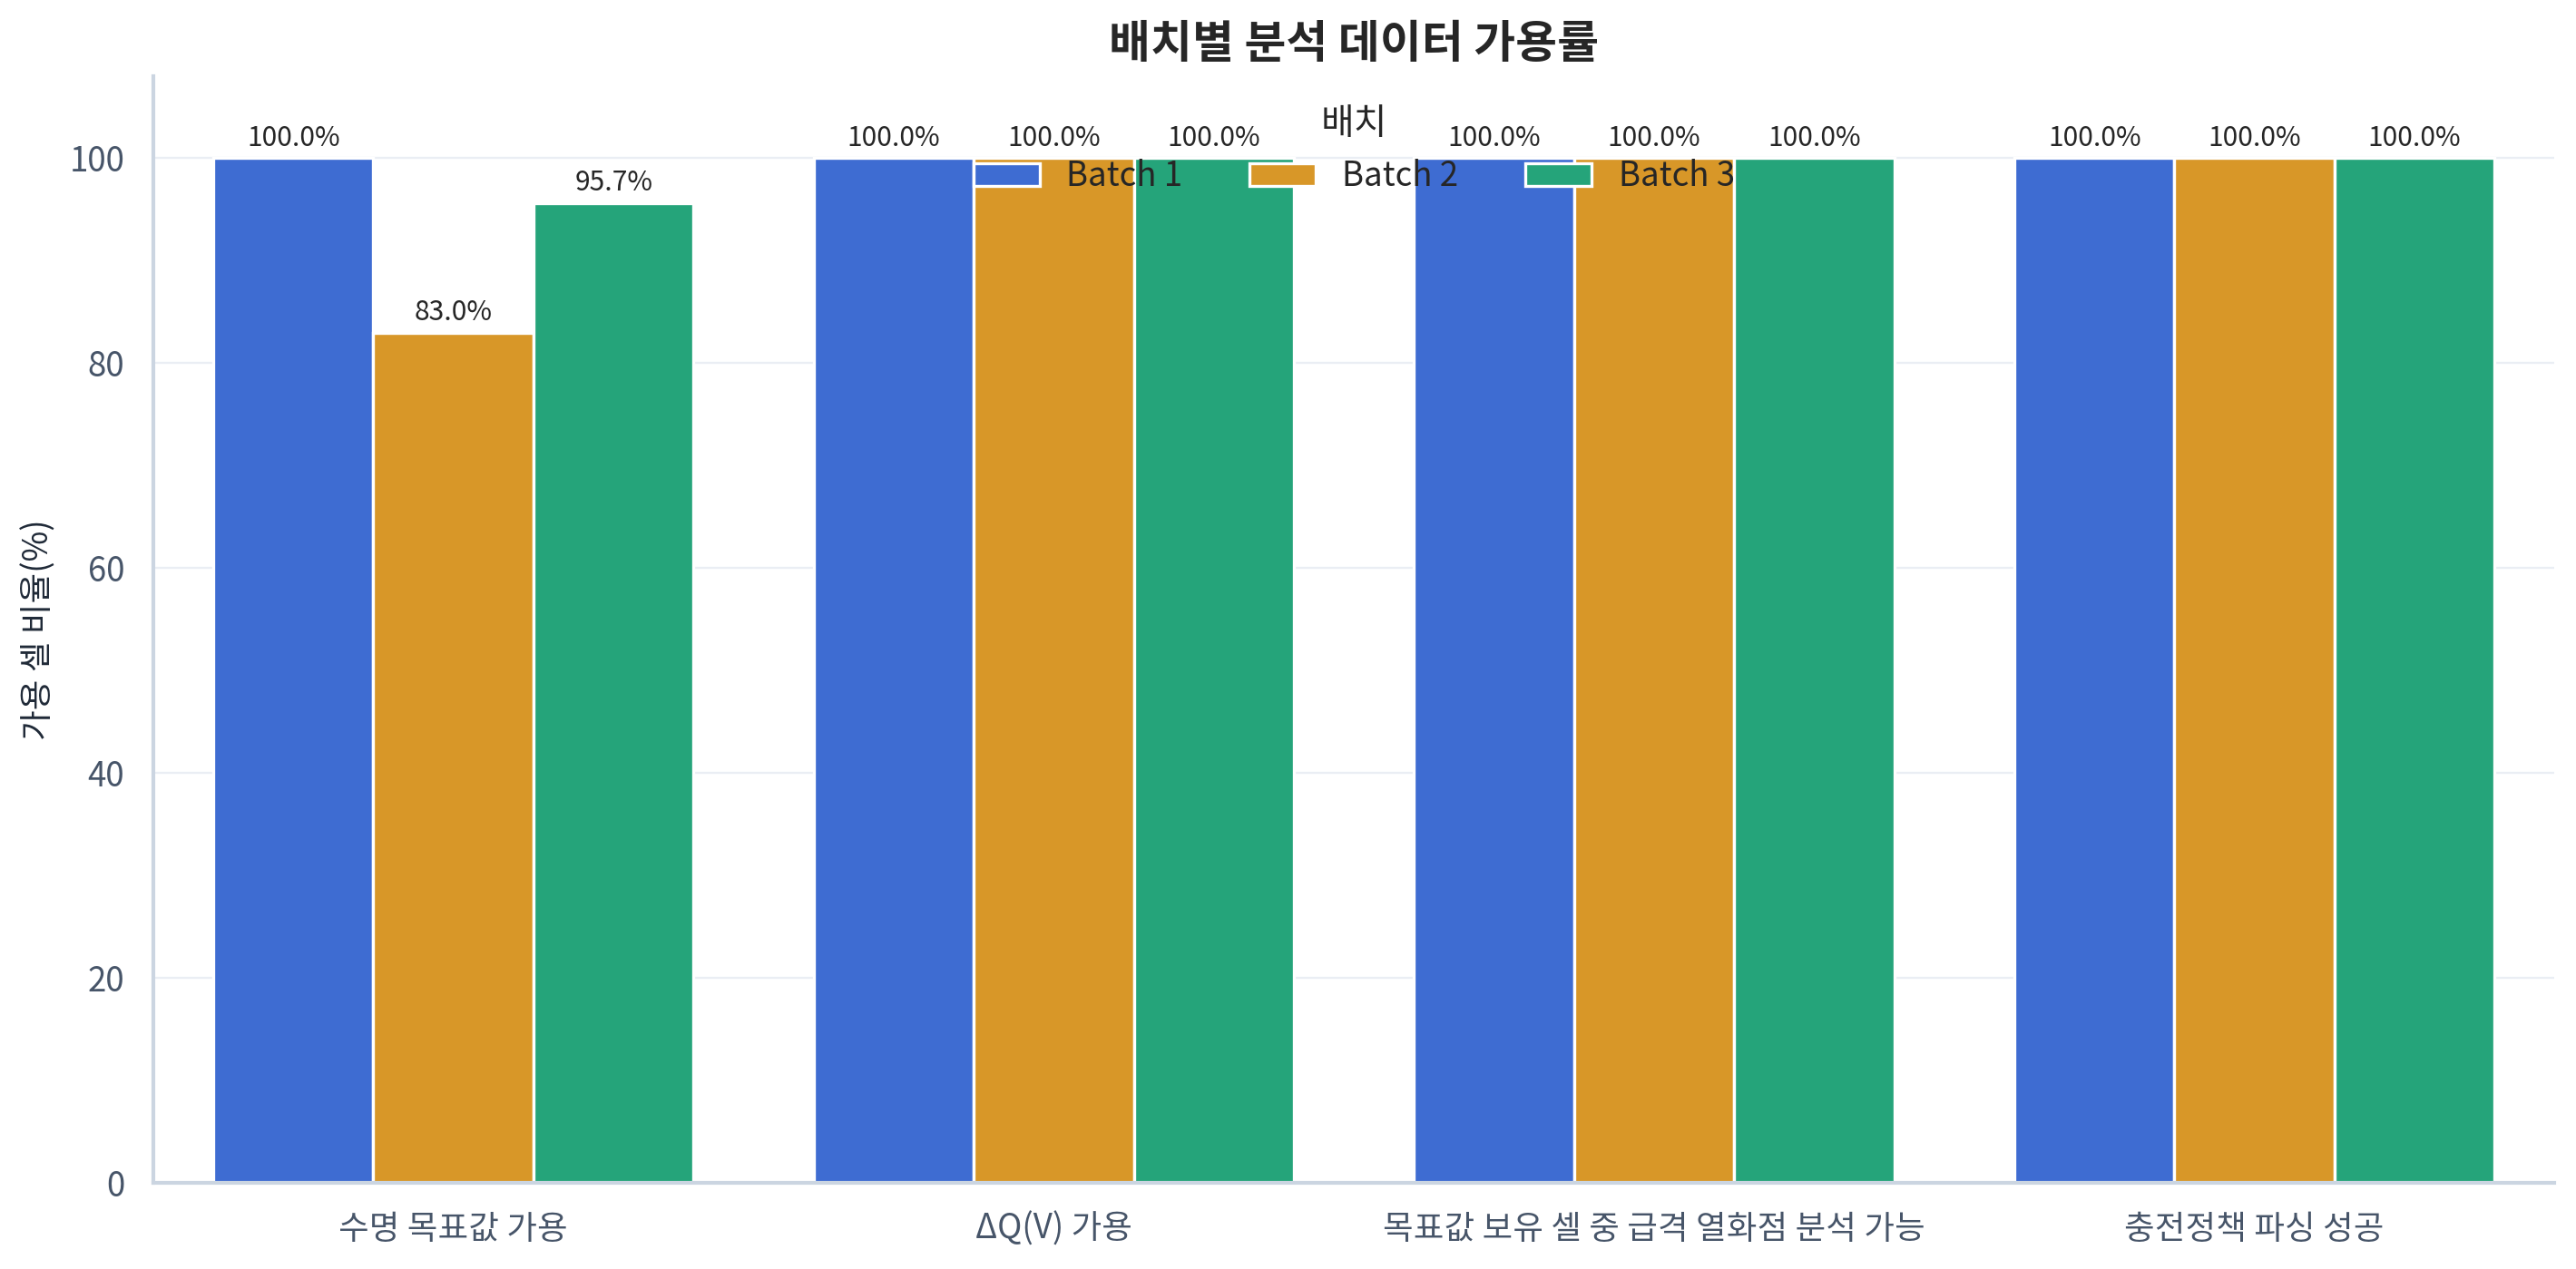

In [3]:
display(pd.read_csv(RESULT_DIR / 'quality_audit.csv'))
display(Image(filename=str(FIGURE_DIR / '00_데이터_품질_가용률.png')))

## 질문 1 — 배터리 수명 분포

,batch,cell_count,mean,median,std,min,q1,q3,max,skew
0,Batch 1,46,844.717391,858.5,184.629198,534.0,703.25,914.25,1227.0,0.452864
1,Batch 2,39,565.743590,472.0,222.201629,392.0,439.50,508.50,1186.0,1.636830
2,Batch 3,44,1059.659091,1005.5,313.869692,541.0,828.00,1155.25,1935.0,1.255079


,batch,life_group,count,total,rate_pct,ci_low_pct,ci_high_pct
0,Batch 1,단수명(<500),0,46,0.000000,-6.938894e-16,7.707618
1,Batch 1,중간수명(500~1000),36,46,78.260870,6.442603e+01,87.739225
2,Batch 1,장수명(>1000),10,46,21.739130,1.226077e+01,35.573966
3,Batch 2,단수명(<500),28,39,71.794872,5.622438e+01,83.456675
4,Batch 2,중간수명(500~1000),8,39,20.512821,1.077959e+01,35.534273
5,Batch 2,장수명(>1000),3,39,7.692308,2.650691e+00,20.321373
6,Batch 3,단수명(<500),0,44,0.000000,6.938894e-16,8.029832
7,Batch 3,중간수명(500~1000),21,44,47.727273,3.375476e+01,62.064780
8,Batch 3,장수명(>1000),23,44,52.272727,3.793522e+01,66.245242


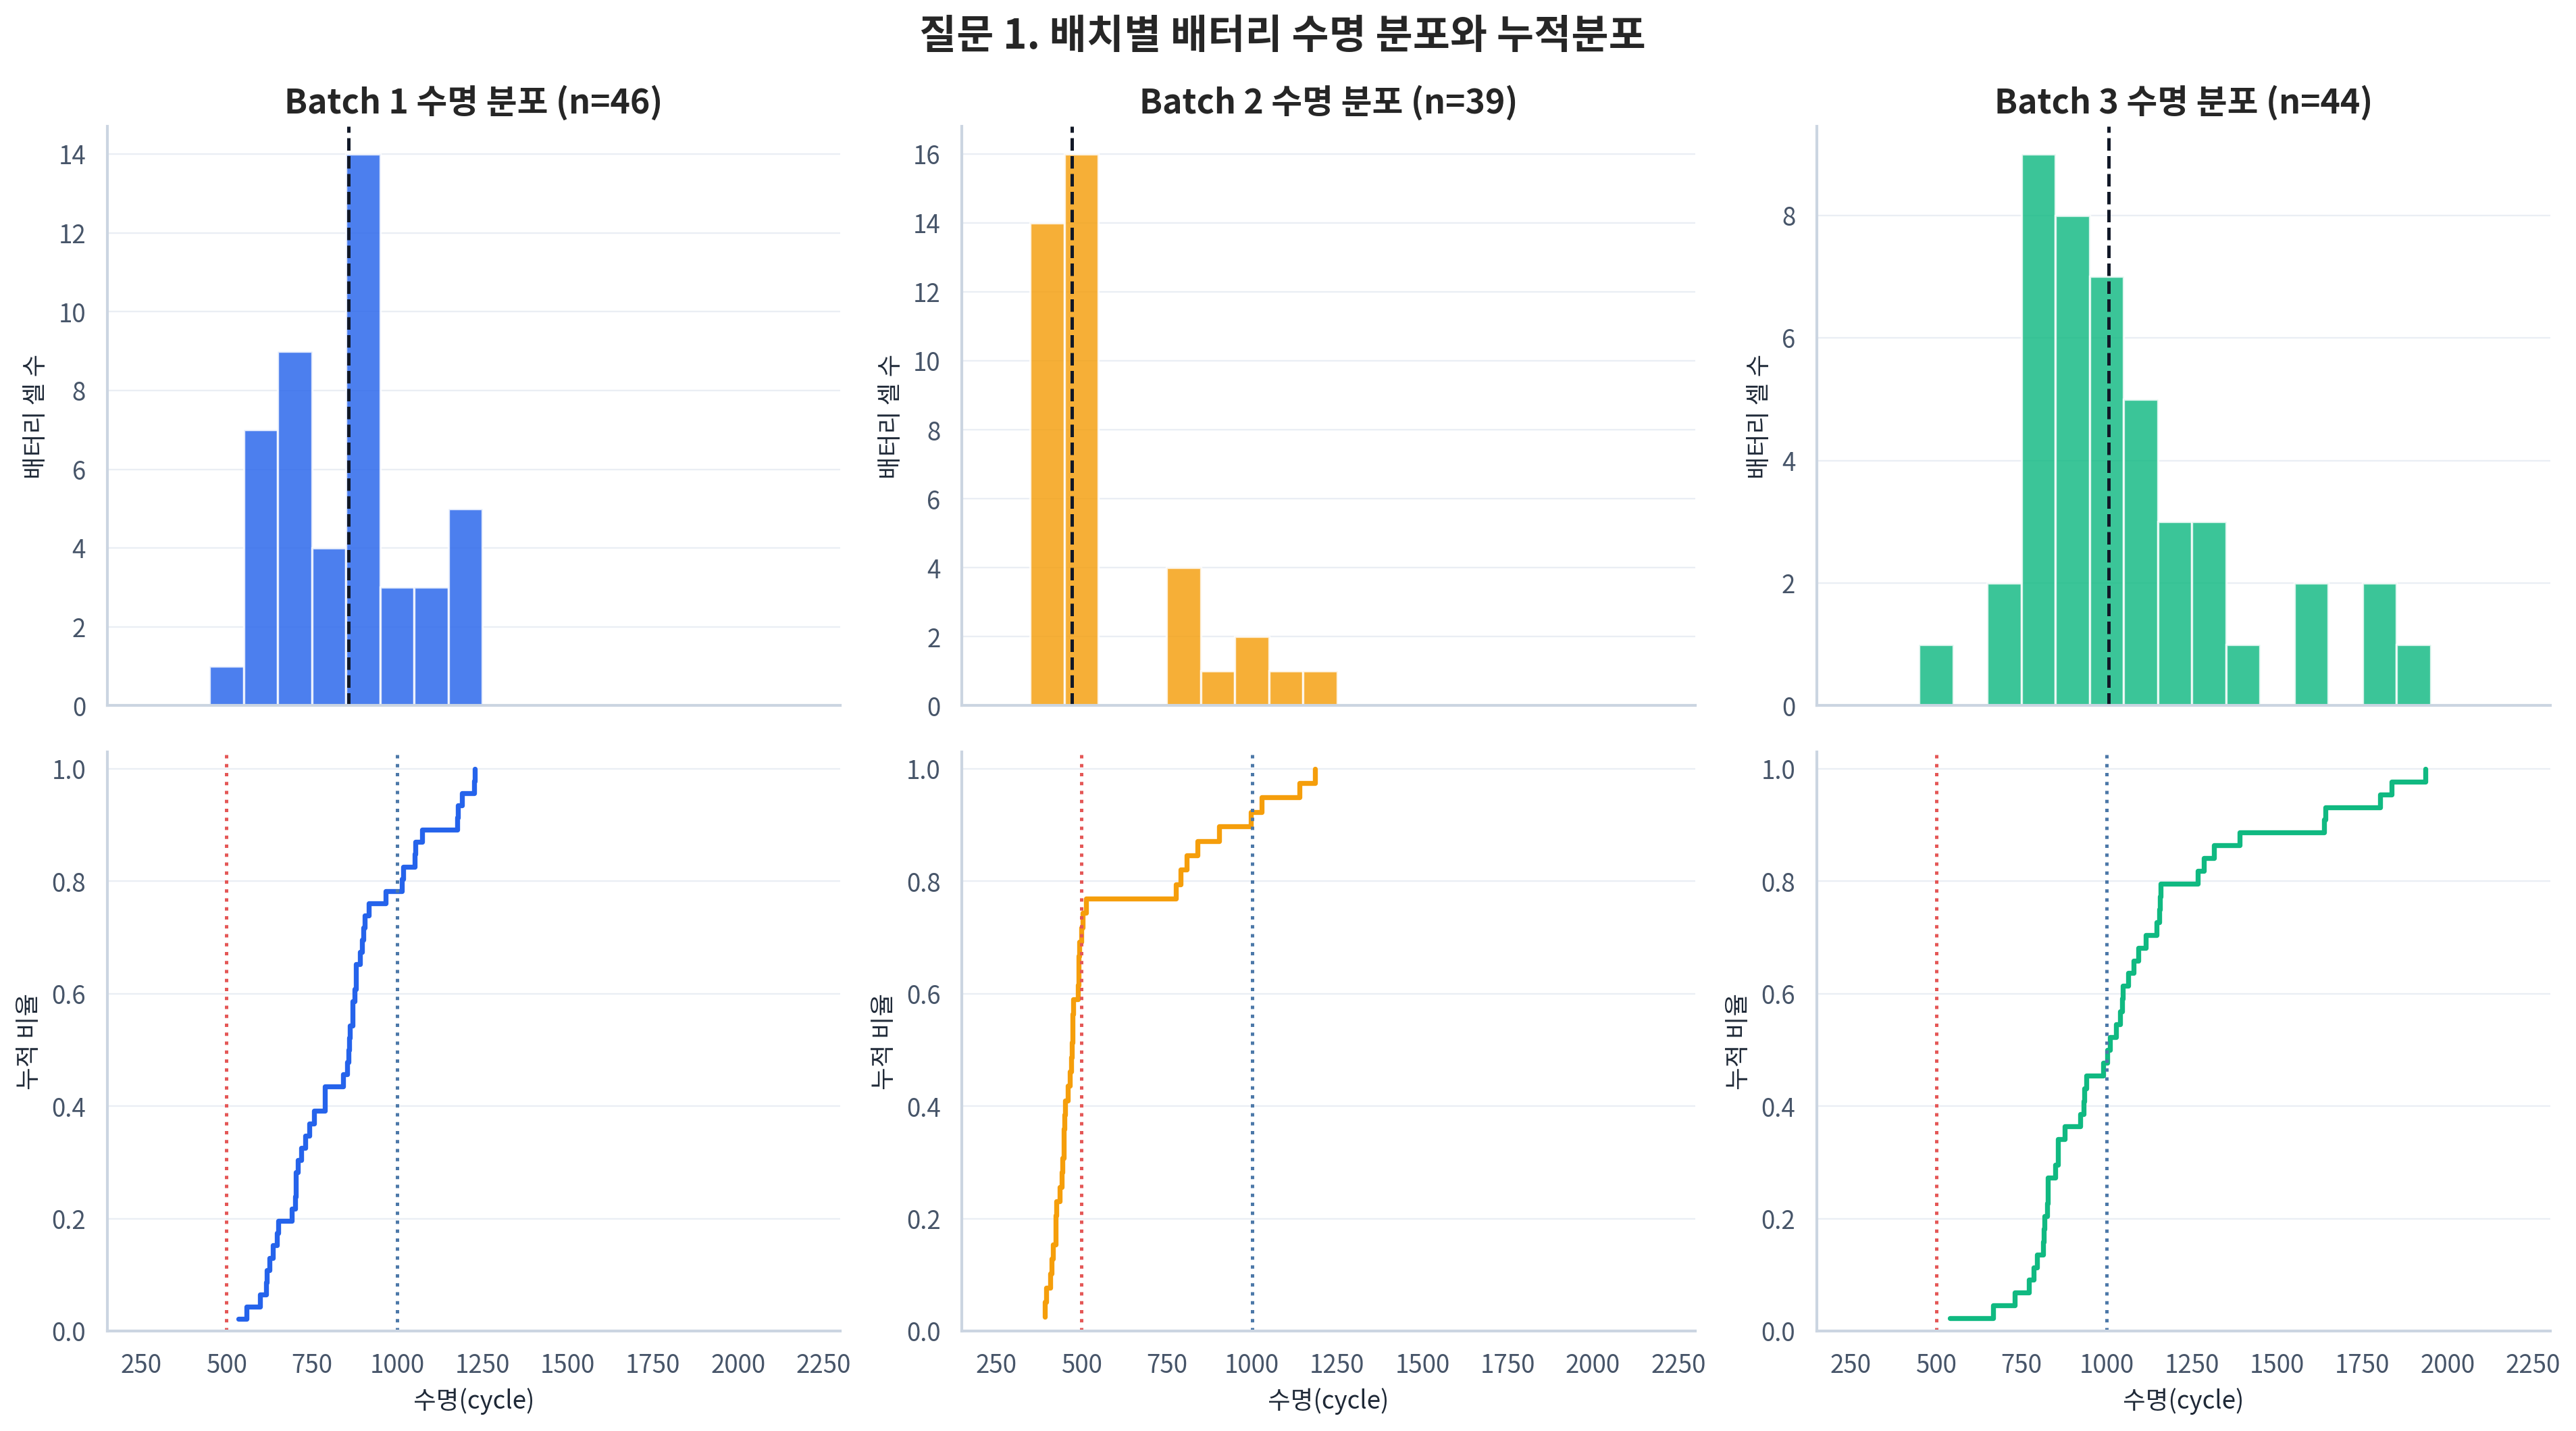

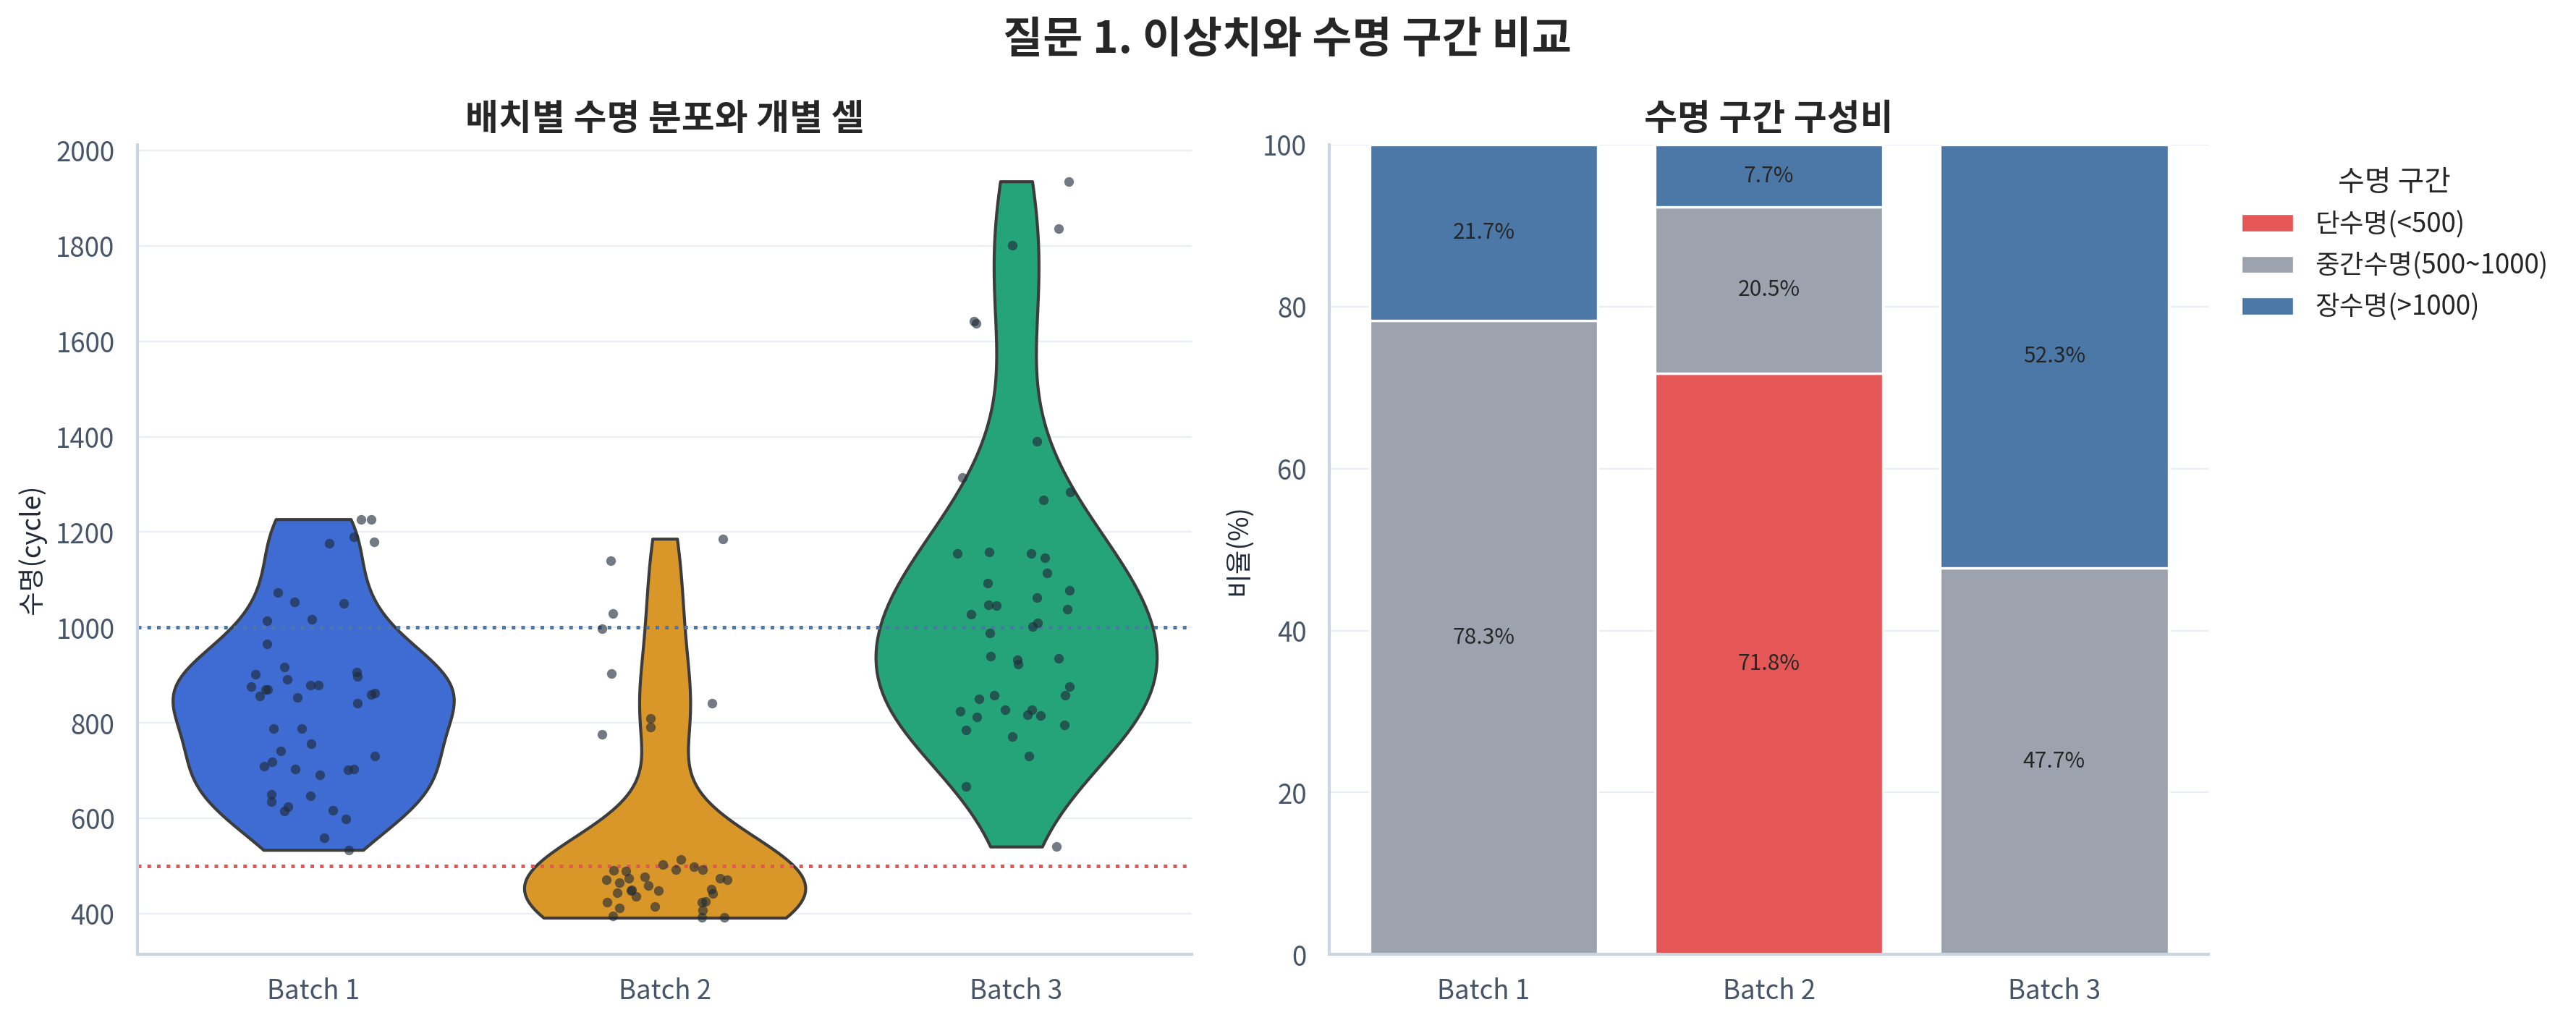

In [4]:
display(pd.read_csv(RESULT_DIR / 'batch_summary.csv'))
display(pd.read_csv(RESULT_DIR / 'lifetime_group_rates.csv'))
display(Image(filename=str(FIGURE_DIR / '01_수명_분포.png')))
display(Image(filename=str(FIGURE_DIR / '02_수명_구간_비율.png')))

## 질문 2 — 방전용량 열화와 급격 열화 시작점

knee_cycle                                                        \
             count        mean         std    min     25%    50%     75%   
batch                                                                      
Batch 1       46.0  608.782609  131.791234  413.0  508.75  601.0  678.25   
Batch 2       39.0  423.179487  184.379310  246.0  314.00  342.0  386.50   
Batch 3       44.0  849.136364  252.324412  377.0  674.75  819.5  910.25   

                knee_fraction_of_life                                          \
            max                 count      mean       std       min       25%   
batch                                                                           
Batch 1   962.0                  46.0  0.730239  0.096762  0.360475  0.737323   
Batch 2   940.0                  39.0  0.739549  0.045585  0.591346  0.714586   
Batch 3  1523.0                  44.0  0.800057  0.036029  0.696858  0.778911   

                                       
              50%       75%       max  
batch                                  
Batch 1  0.749571  0.766545  0.820298  
Batch 2  0.747242  0.771083  0.821641  
Batch 3  0.793862  0.826232  0.866782

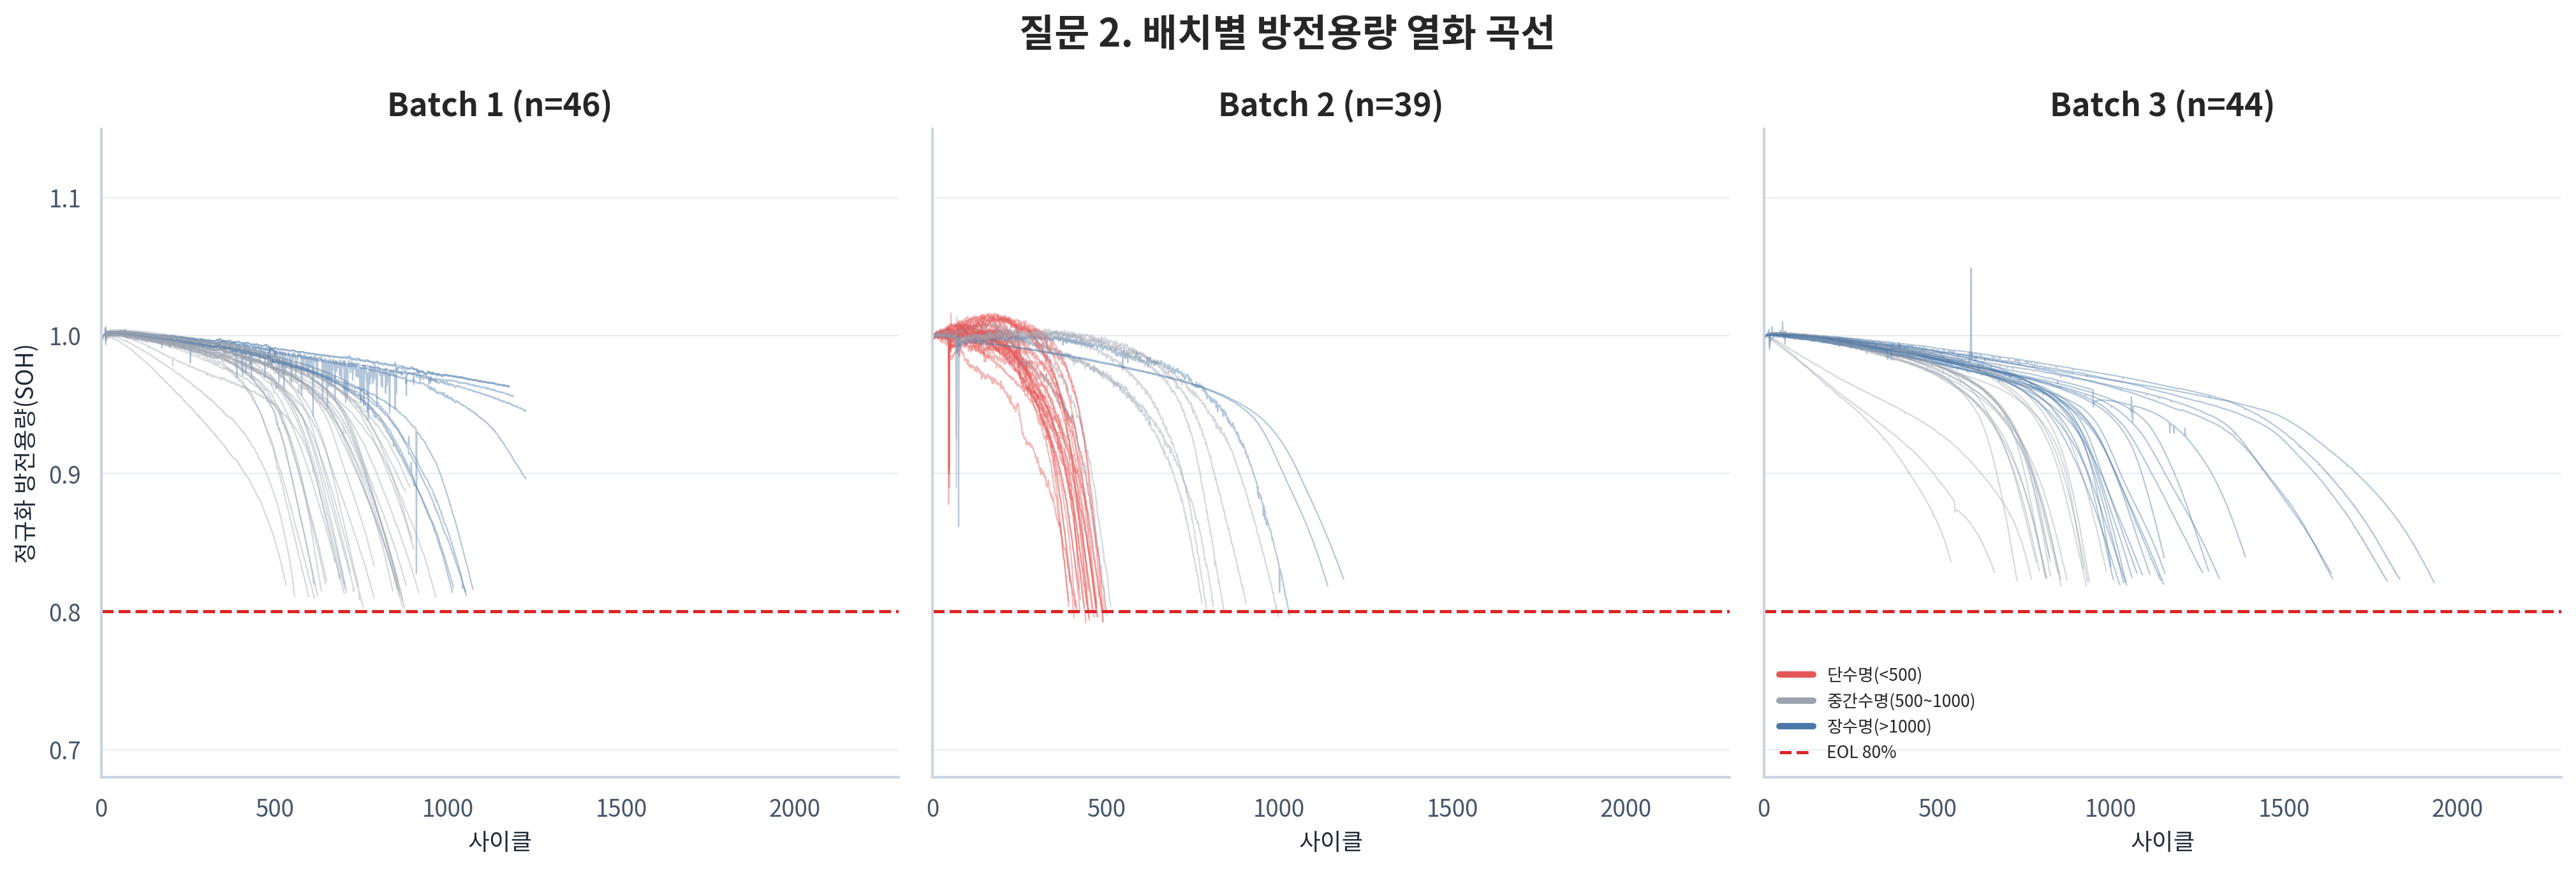

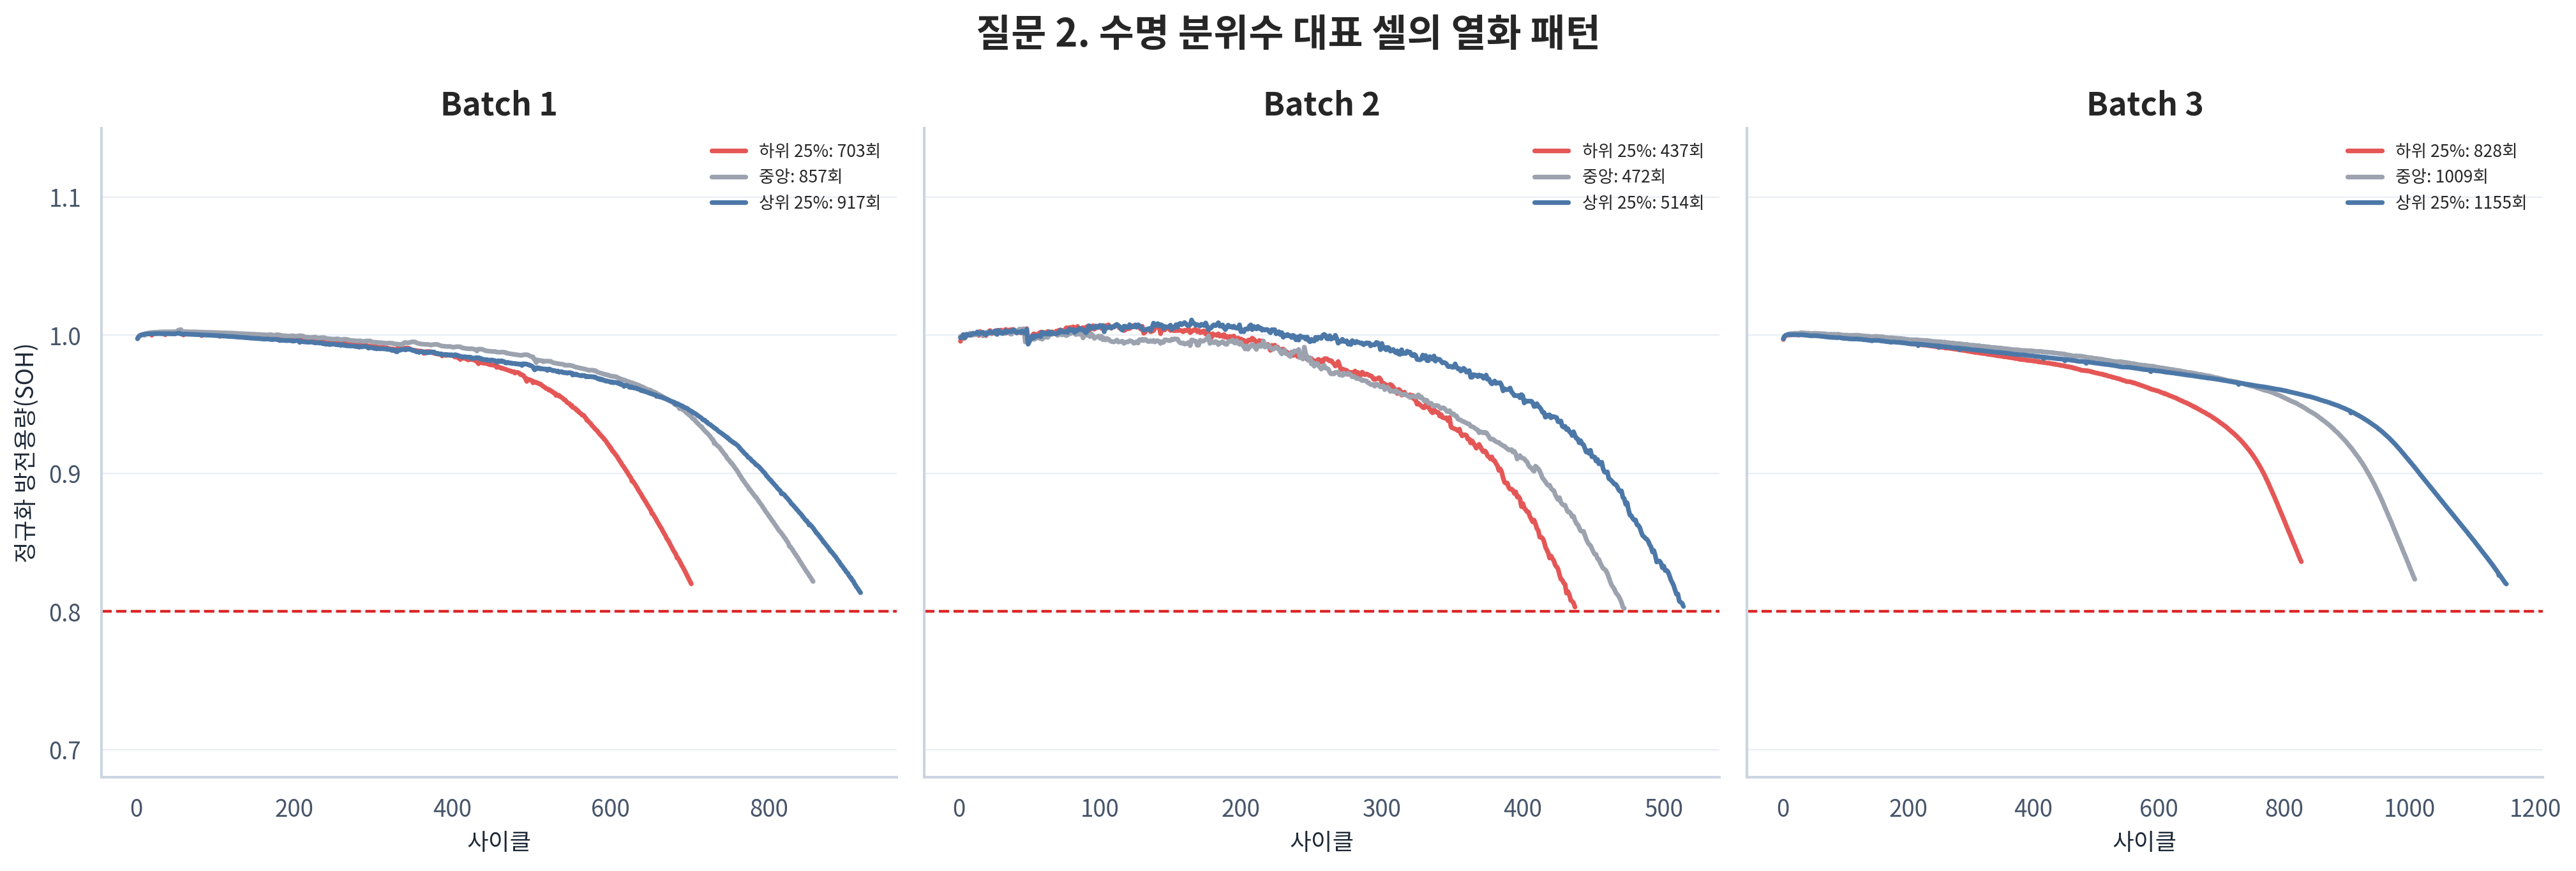

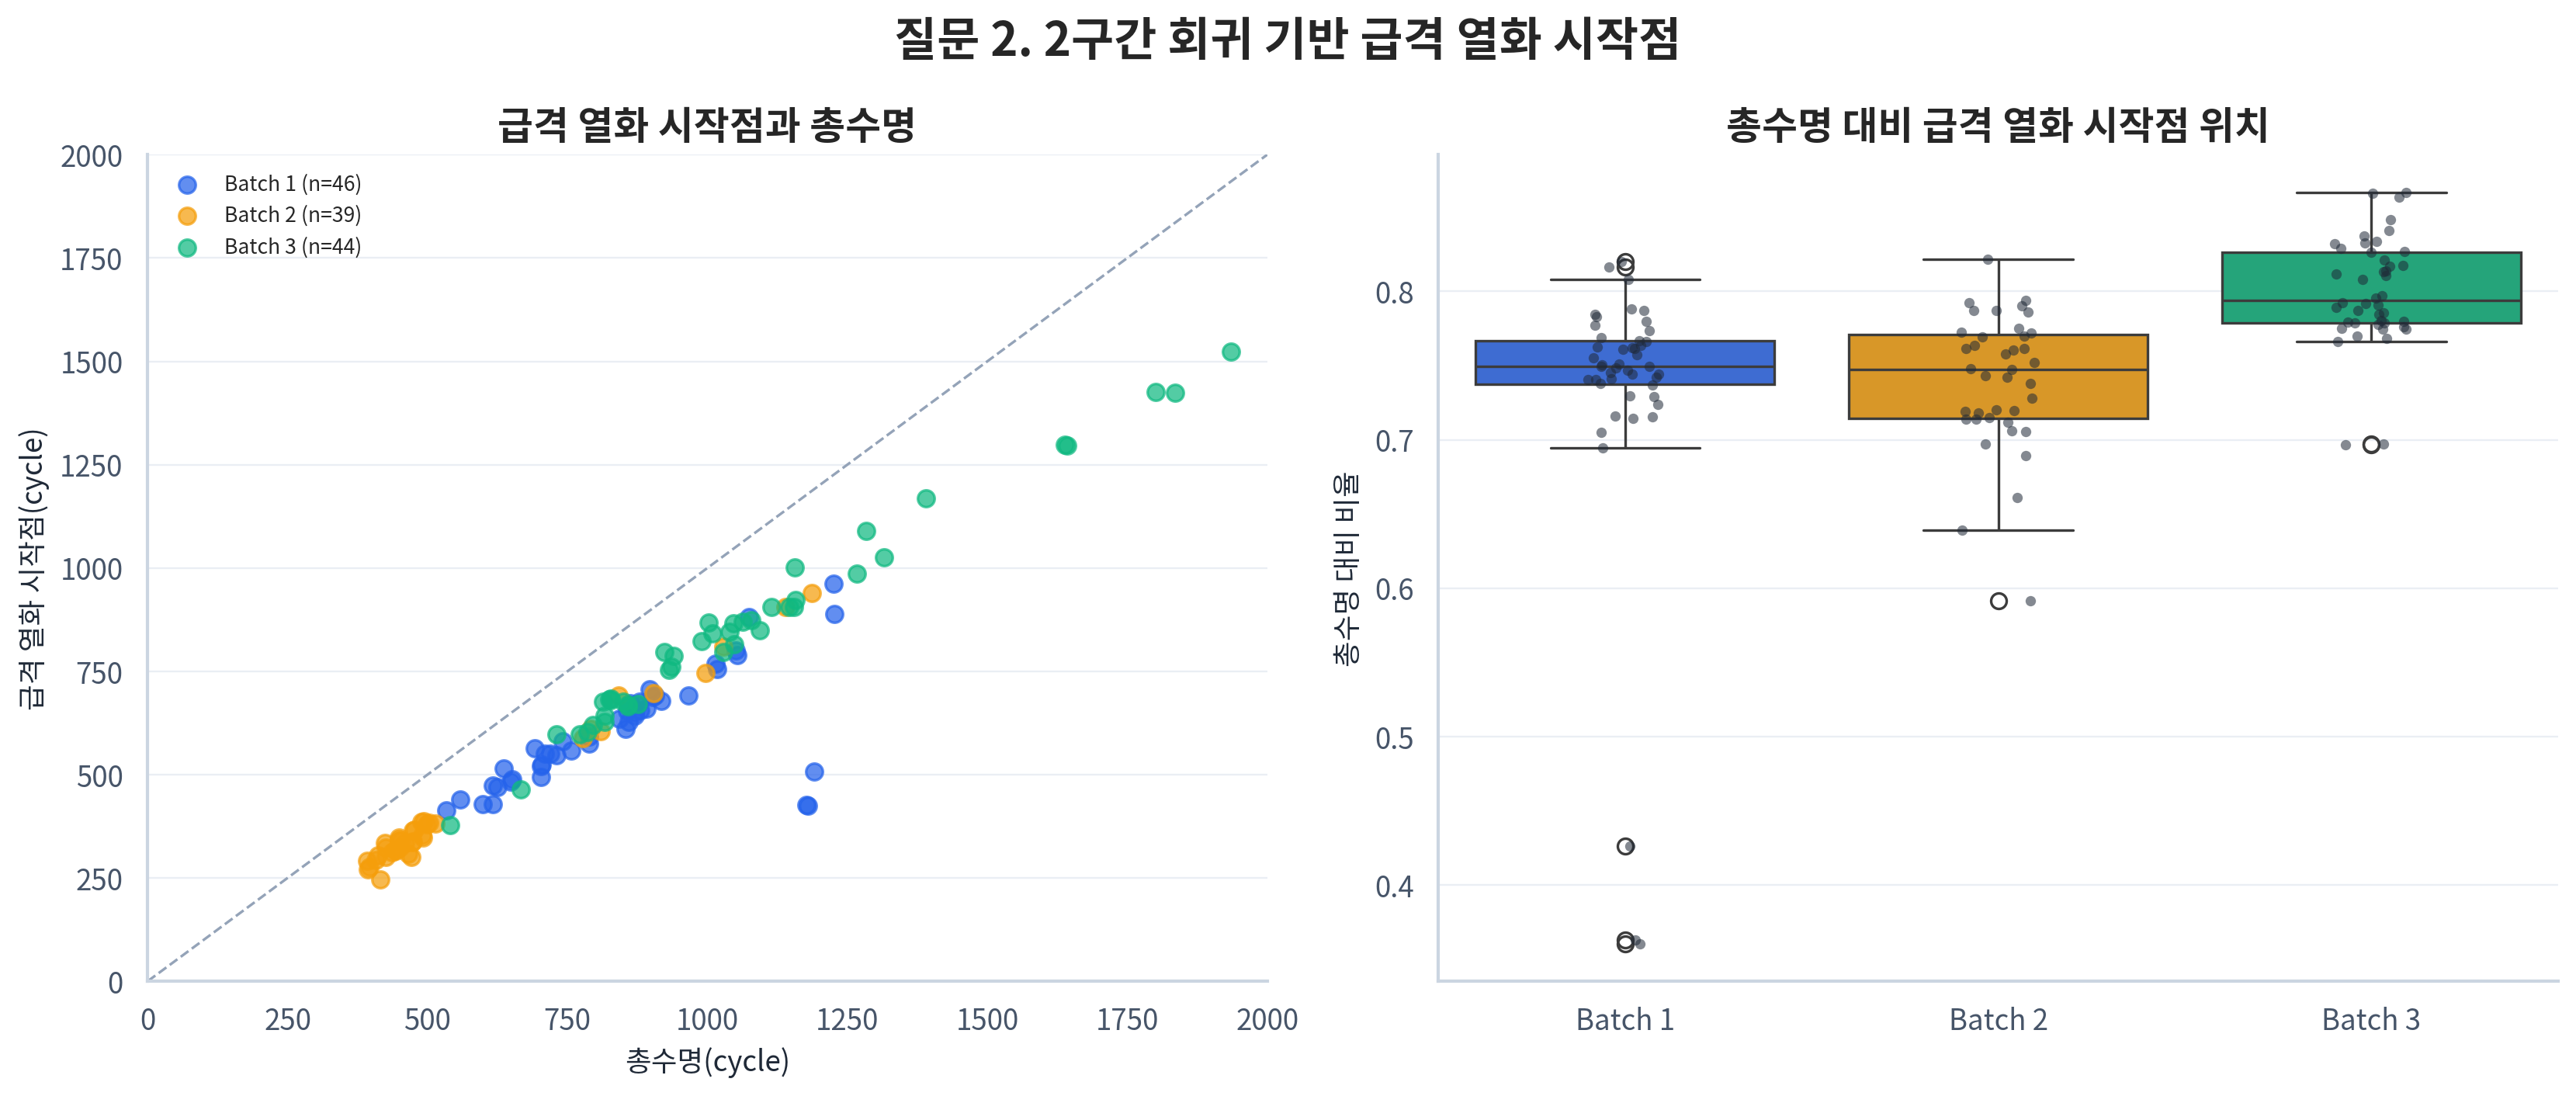

In [5]:
display(pd.read_csv(RESULT_DIR / 'knee_points.csv').groupby('batch')[['knee_cycle', 'knee_fraction_of_life']].describe())
display(Image(filename=str(FIGURE_DIR / '03_열화_곡선.png')))
display(Image(filename=str(FIGURE_DIR / '04_대표_셀_열화.png')))
display(Image(filename=str(FIGURE_DIR / '05_knee_point_분석.png')))

## 질문 3 — 초기 ΔQ(V) 신호

,batch,cell_index,global_cell_id,cycle_life,life_group,charging_policy,policy_parse_success,policy_type,c_rate_stage1,switch_soc_pct,...,delta_q_min_voltage,delta_q_max_voltage,delta_q_area,delta_q_abs_area,delta_q_l1,delta_q_l2,delta_q_skew,delta_q_kurtosis,delta_q_available,delta_q_reason
0,Batch 1,0,Batch1_000,1190.0,장수명(>1000),3.6C(80%)-3.6C,True,2단계 정전류,3.6,80.0,...,3.064565,2.000000,-0.004315,0.004437,0.002955,0.004233,-0.532858,-1.349054,True,계산 완료
1,Batch 1,1,Batch1_001,1179.0,장수명(>1000),3.6C(80%)-3.6C,True,2단계 정전류,3.6,80.0,...,3.136637,3.478979,-0.006155,0.006155,0.004100,0.005147,-0.430020,-1.028256,True,계산 완료
2,Batch 1,2,Batch1_002,1177.0,장수명(>1000),3.6C(80%)-3.6C,True,2단계 정전류,3.6,80.0,...,3.153153,3.481982,-0.006736,0.006737,0.004487,0.006201,-1.081818,0.356410,True,계산 완료
3,Batch 1,3,Batch1_003,1226.0,장수명(>1000),4C(80%)-4C,True,2단계 정전류,4.0,80.0,...,2.957958,3.500000,-0.011194,0.011212,0.007468,0.009575,-0.439710,-1.094889,True,계산 완료
4,Batch 1,4,Batch1_004,1227.0,장수명(>1000),4C(80%)-4C,True,2단계 정전류,4.0,80.0,...,2.878378,3.495495,-0.008633,0.008635,0.005751,0.007454,-0.363093,-1.334500,True,계산 완료


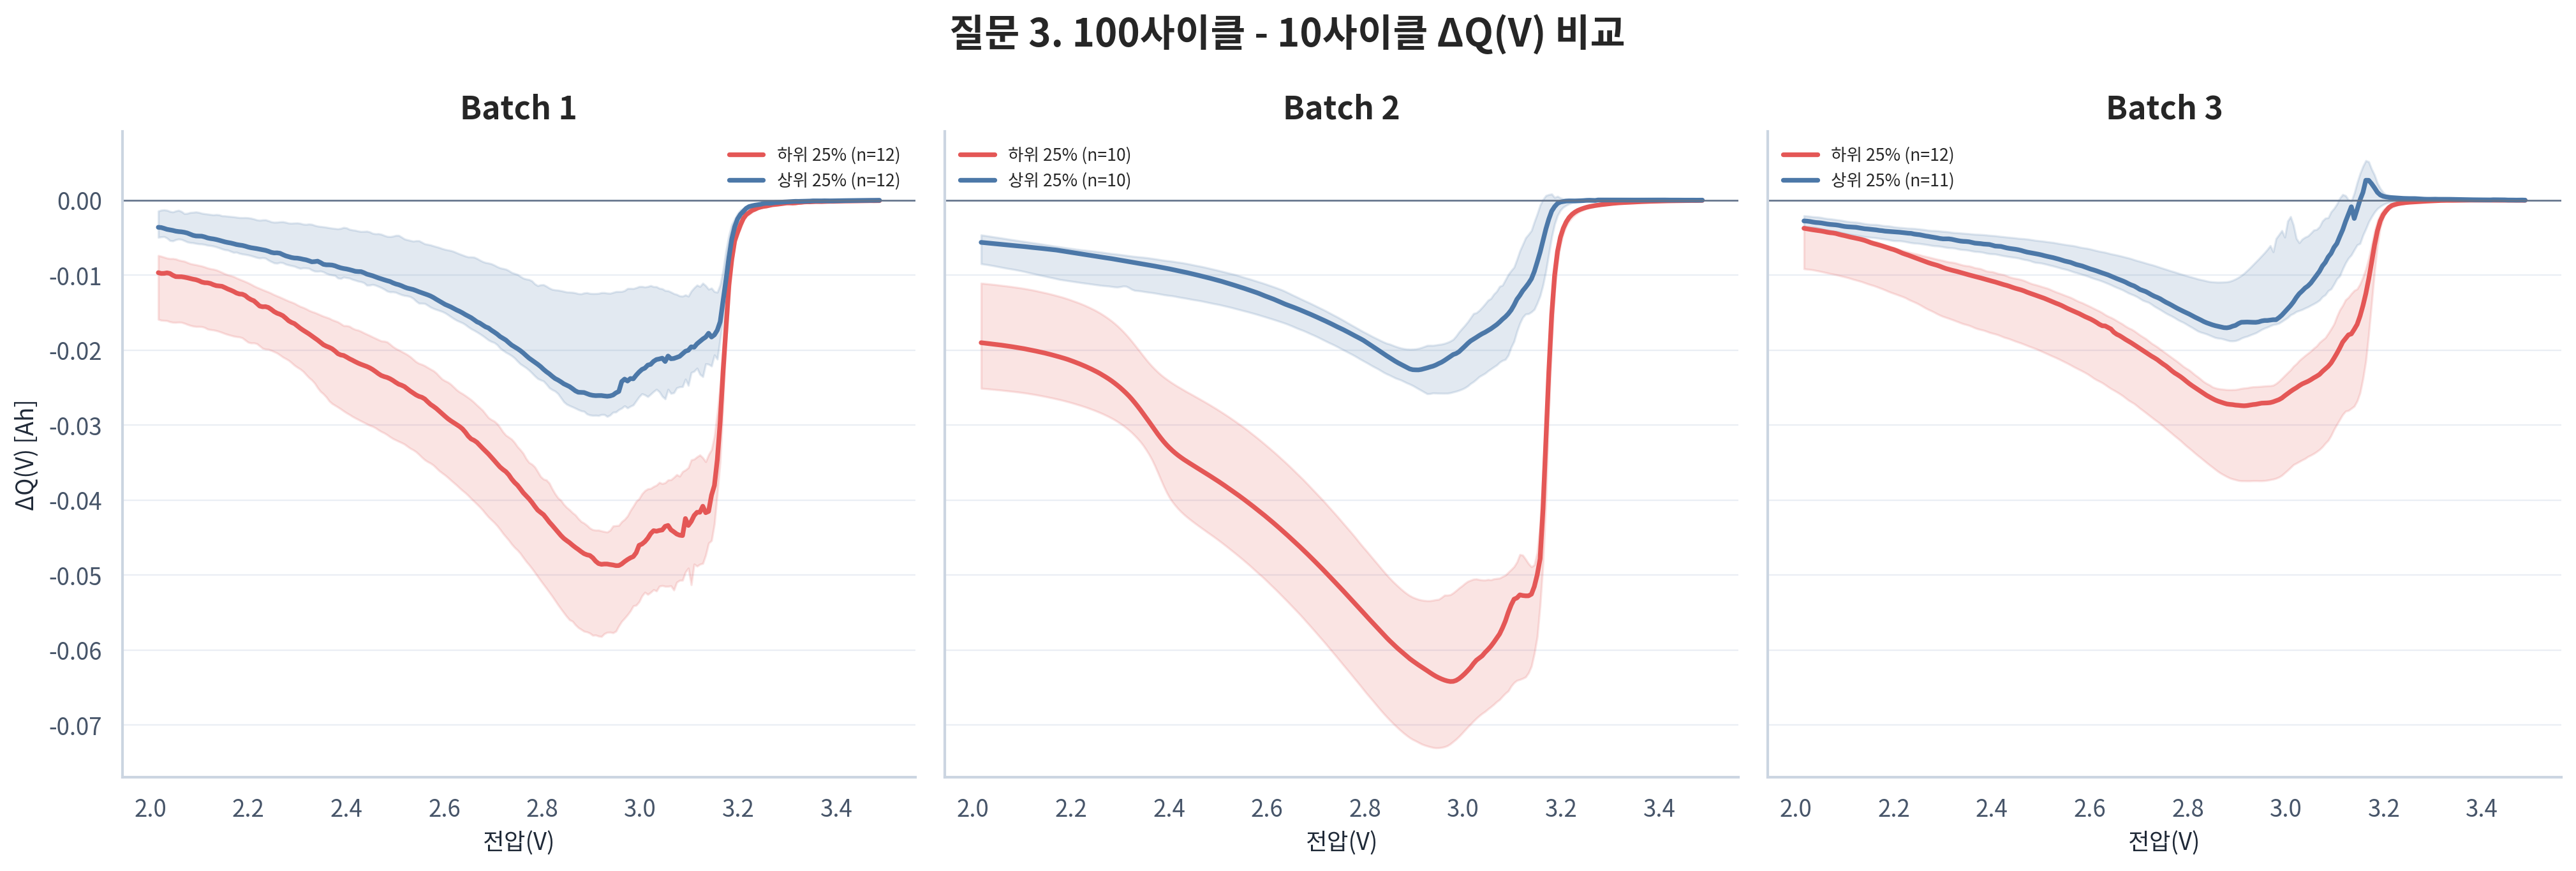

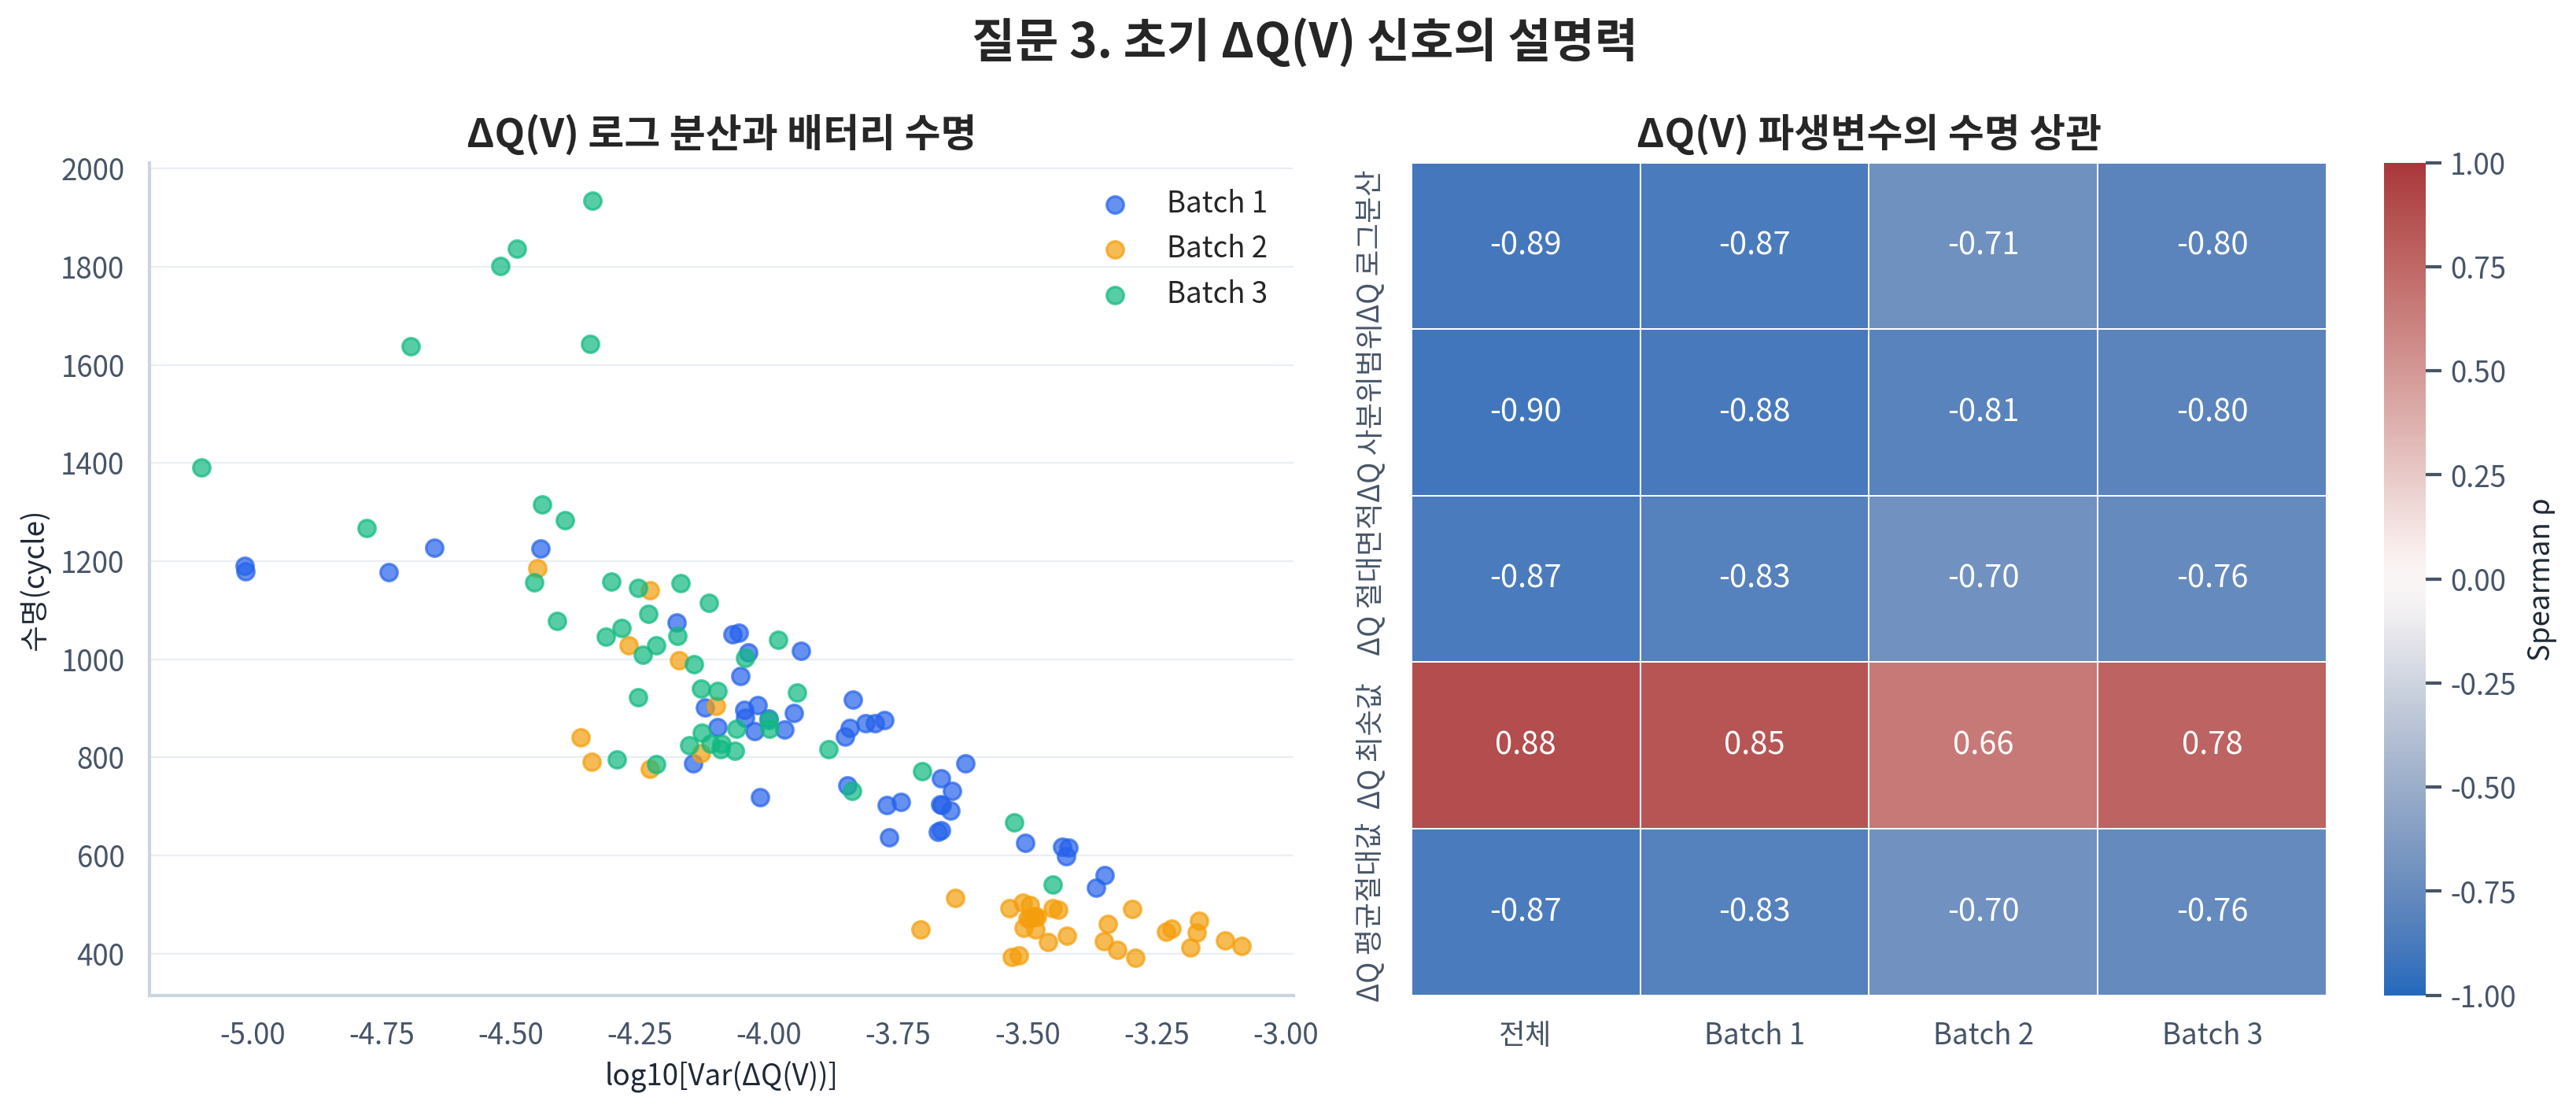

In [6]:
display(pd.read_csv(RESULT_DIR / 'delta_q_features.csv').head())
display(Image(filename=str(FIGURE_DIR / '06_deltaQ_곡선.png')))
display(Image(filename=str(FIGURE_DIR / '07_deltaQ_상관.png')))

## 질문 4 — 충전 조건과 수명

,batch,charging_policy,n,mean_cycle_life,median_cycle_life,std_cycle_life,bootstrap_ci_low,bootstrap_ci_high
37,Batch 3,5.3C(54%)-4C-newstructure,8,1074.375000,1051.0,129.674248,998.621875,1165.878125
38,Batch 3,5.6C(19%)-4.6C-newstructure,8,1001.375000,1038.0,174.555712,888.612500,1109.375000
39,Batch 3,5.6C(36%)-4.3C-newstructure,8,930.875000,890.5,135.024270,848.996875,1018.003125
42,Batch 3,5C(67%)-4C-newstructure,7,1105.714286,1009.0,402.911783,885.107143,1397.867857
36,Batch 3,4.8C(80%)-4.8C-newstructure,6,1564.166667,1640.0,285.721834,1343.833333,1744.166667
32,Batch 2,5.6C(26%)-4.5C,6,448.500000,446.0,29.125590,427.666667,469.670833
27,Batch 2,4.8C(80%)-4.8C,5,483.600000,492.0,30.319960,457.200000,505.200000
29,Batch 2,5.2C(50%)-4.25C,5,454.000000,449.0,20.916501,439.000000,469.000000
30,Batch 2,5.2C(58%)-4C,4,477.750000,483.0,18.463929,461.250000,491.000000
0,Batch 1,3.6C(80%)-3.6C,3,1182.000000,1179.0,7.000000,1177.000000,1190.000000


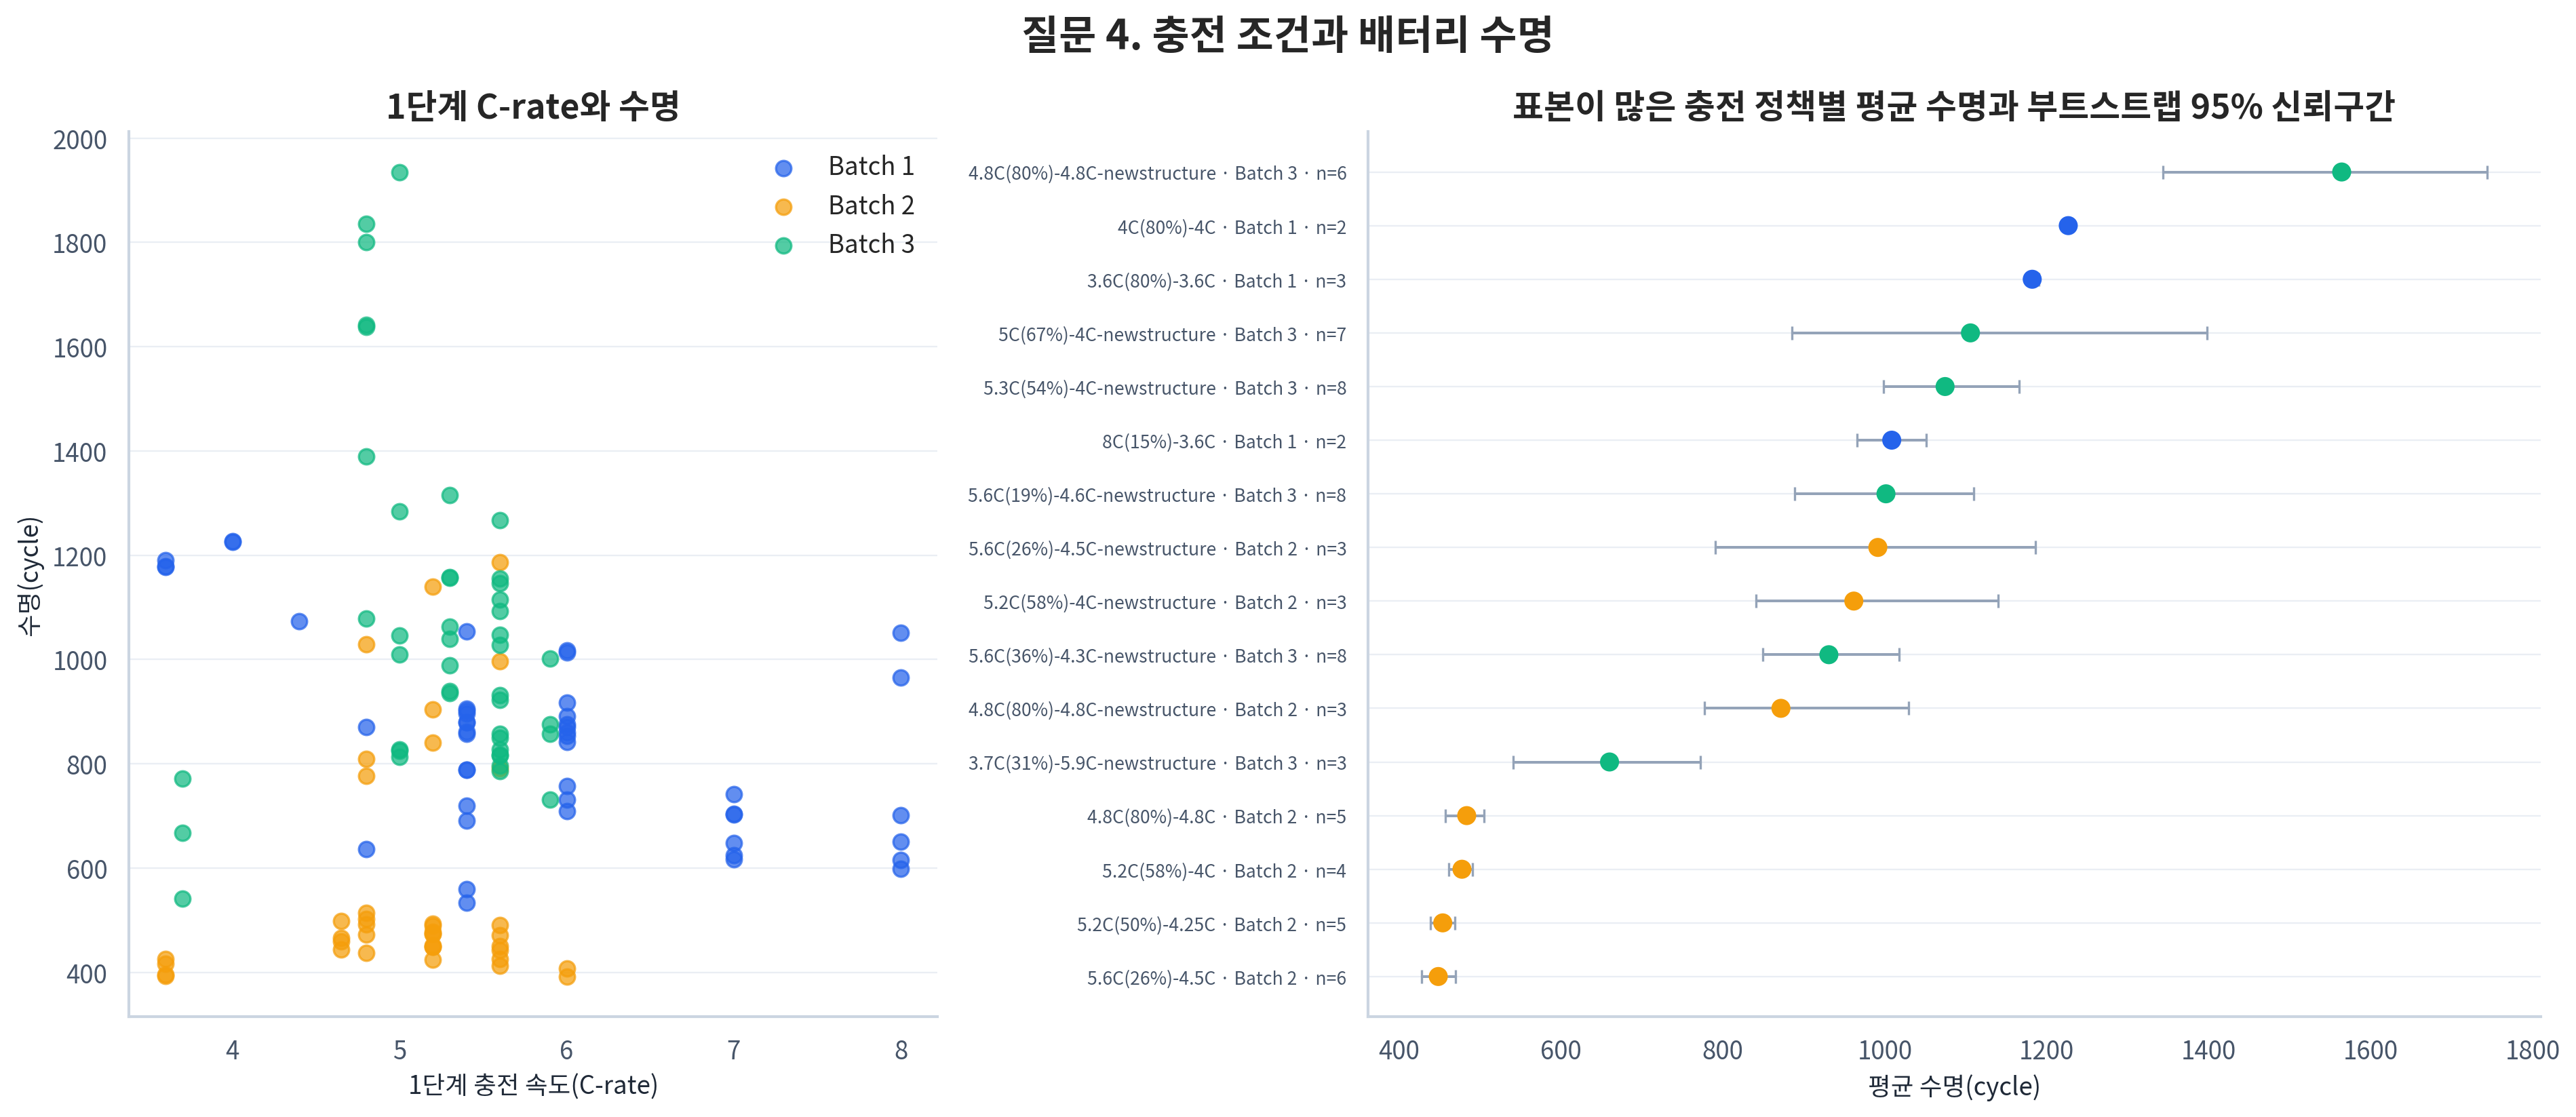

In [7]:
display(pd.read_csv(RESULT_DIR / 'policy_summary.csv').sort_values(['n', 'mean_cycle_life'], ascending=[False, False]).head(20))
display(Image(filename=str(FIGURE_DIR / '08_충전_정책.png')))

## 질문 5 — 초기 신호와 수명 및 최종 feature 결정

,scope,feature,n,pearson_r,pearson_p,spearman_r,spearman_p,spearman_p_bh,abs_spearman
139,Batch 1,delta_q_iqr,46,-0.909102,2.419039e-18,-0.879364,8.945793e-16,6.447247e-14,0.879364
131,Batch 1,delta_q_std,46,-0.893713,6.422592e-17,-0.871161,3.484999e-15,6.447247e-14,0.871161
132,Batch 1,delta_q_var,46,-0.837826,3.845425e-13,-0.871161,3.484999e-15,6.447247e-14,0.871161
133,Batch 1,delta_q_log10_var,46,-0.886123,2.702897e-16,-0.871161,3.484999e-15,6.447247e-14,0.871161
134,Batch 1,delta_q_q05,46,0.885424,3.069596e-16,0.856359,3.254069e-14,4.816022e-13,0.856359
128,Batch 1,delta_q_min,46,0.881645,6.021711e-16,0.850006,7.873942e-14,9.711195e-13,0.850006
135,Batch 1,delta_q_q25,46,0.872529,2.795976e-15,0.844825,1.571573e-13,1.661377e-12,0.844825
145,Batch 1,delta_q_l2,46,-0.869088,4.842431e-15,-0.843345,1.905856e-13,1.762917e-12,0.843345
142,Batch 1,delta_q_area,46,0.853841,4.641608e-14,0.828112,1.244280e-12,7.673058e-12,0.828112
143,Batch 1,delta_q_abs_area,46,-0.853825,4.652012e-14,-0.828112,1.244280e-12,7.673058e-12,0.828112


,feature,source,cycle_range,formula,missing_handling,pooled_spearman,availability_pct,decision,reason,leakage_risk,batch_1_spearman,batch_2_spearman,batch_3_spearman,batch_direction_consistency
0,delta_q_log10_var,Qdlin,"10, 100",log10(var(Q100-Q10)+1e-12),두 곡선이 모두 유효한 셀만 계산; pipeline에서 대체,-0.892074,100.000000,우선 채택,초기 열화 형상을 압축하며 원논문 핵심 계열 feature,낮음: 100사이클 이내,-0.871161,-0.708979,-0.797237,동일 방향
1,delta_q_min,Qdlin,"10, 100",min(Q100-Q10),ΔQ(V) 미가용 셀은 대체 및 결측 flag,0.883398,100.000000,후보 채택,곡선의 국소 열화 강도 반영,낮음,0.850006,0.660897,0.776024,동일 방향
2,qd_slope,summary.QDischarge,2~100,QD~cycle 선형회귀 기울기,물리 범위 밖 값 제외 후 계산,-0.184248,100.000000,조건부 후보,초기 용량 변화 속도를 반영하지만 배치별 상관 방향이 달라 CV·ablation 필요,낮음,0.478784,-0.271080,0.088237,방향 불일치
3,ir_slope,summary.IR,2~100,IR~cycle 선형회귀 기울기,비정상·0값 제외,-0.096488,94.964029,조건부 후보,저항 증가율 후보이나 Batch 2 결측과 배치별 방향 불일치 확인 필요,낮음,-0.323424,0.210913,-0.203115,방향 불일치
4,tavg_mean,summary.Tavg,2~100,초기 평균 온도,5~80°C 유효 범위,0.189660,100.000000,조건부 후보,열 스트레스 후보이나 배치별 상관 방향이 달라 Batch 1 CV에서 검증,낮음,-0.371469,0.165503,0.025372,방향 불일치
5,tmax_mean,summary.Tmax,2~100,초기 최고온도의 평균,5~80°C 유효 범위,-0.011477,99.280576,조건부/중복 검토,Tavg와 강한 공선성 가능; CV에서 한 변수만 선택 검토,낮음,-0.322992,-0.135945,-0.035098,동일 방향
6,chargetime_mean,summary.chargetime,2~100,초기 평균 충전 시간,0.1~120분 범위,-0.047781,100.000000,조건부 후보,C-rate의 연속형 대리 변수이나 배치별 관계 반전이 커 민감도 분석 필요,낮음,0.619280,-0.756251,0.191980,방향 불일치
7,c_rate_stage1 / switch_soc_pct / c_rate_stage2,policy_readable,실험 설정,충전 정책 문자열 정규식 파싱,가변 충전·미파싱 정책에 결측 flag,-0.027452,100.000000,조건부 후보,미지 정책 일반화에 유리하나 배치·셀구조 교란과 방향 불일치가 큼,낮음; 운영 시 사전 가용성 확인,-0.482714,0.055093,-0.228875,방향 불일치
8,knee_cycle,전체 QD 곡선,전체 수명,2구간 회귀 SSE 최소점,불완전 곡선은 미계산,NaN,NaN,Day 2 입력에서 제외,설명용으로 유용하지만 미래 전체 수명 정보 사용,매우 높음,NaN,NaN,NaN,해당 없음
9,cycle_life / EOL 파생값,target,전체 수명,target 또는 target 파생,해당 없음,NaN,100.000000,제외,정답 누수,매우 높음,NaN,NaN,NaN,해당 없음


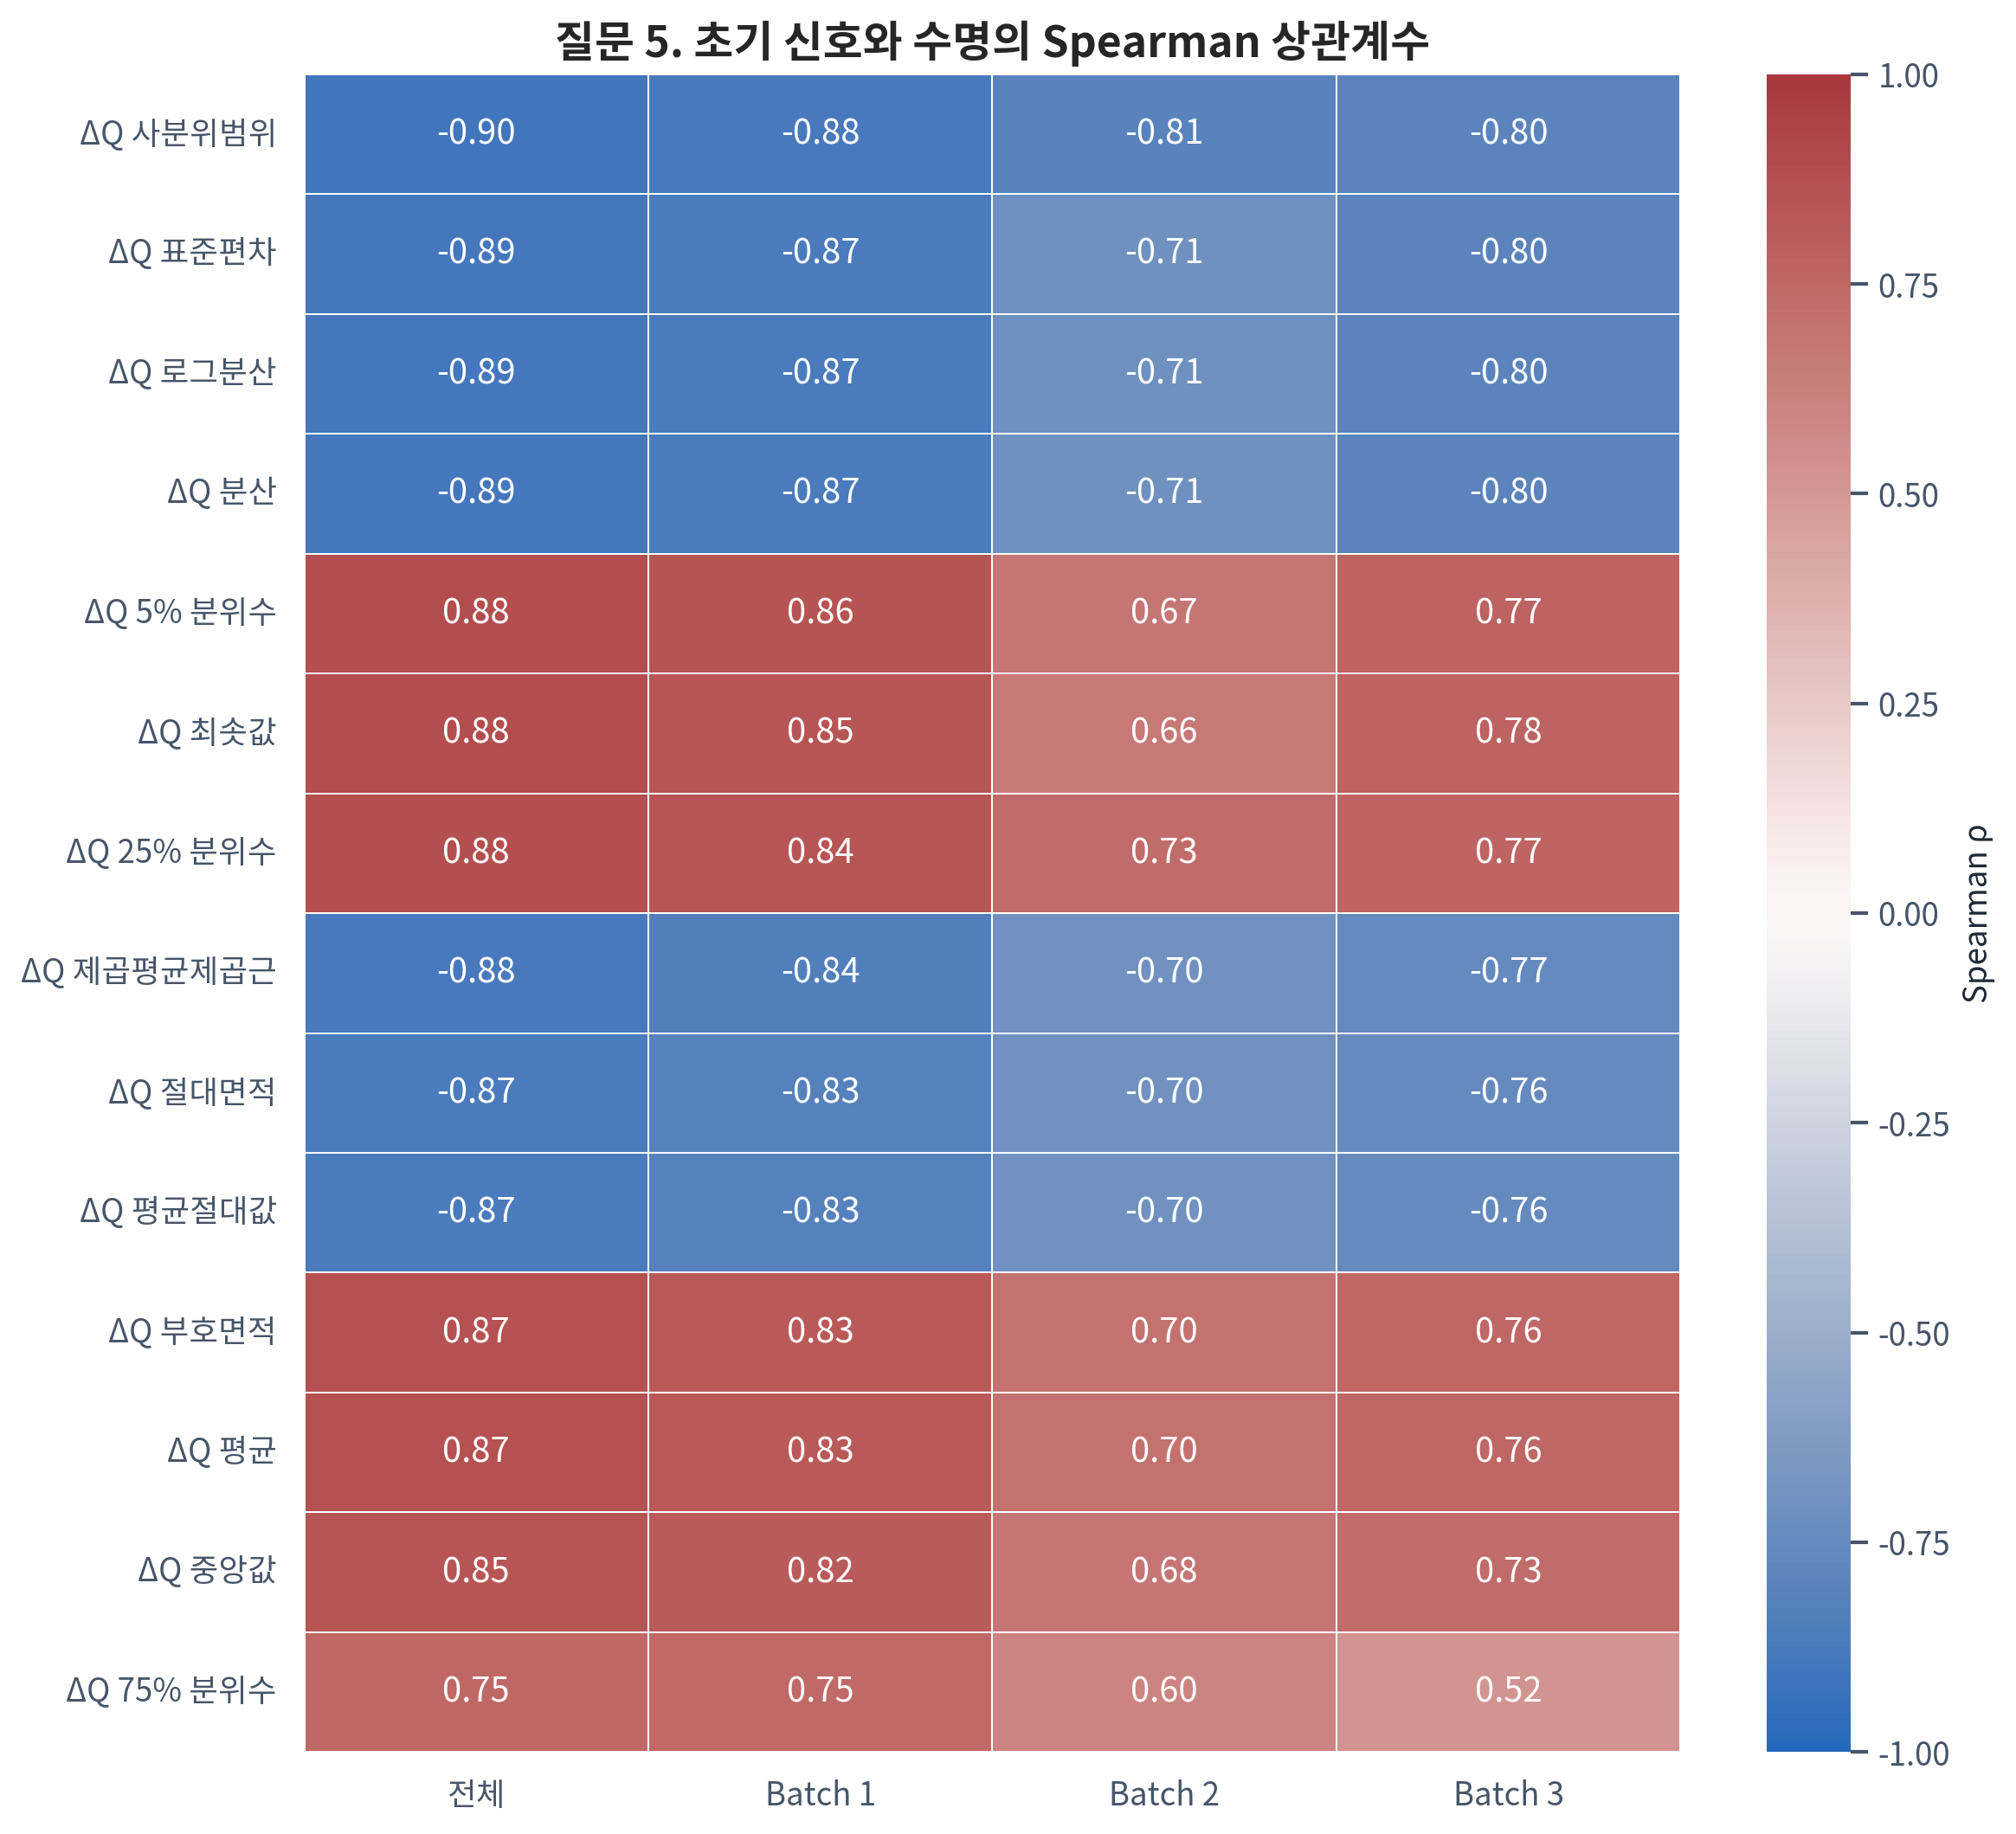

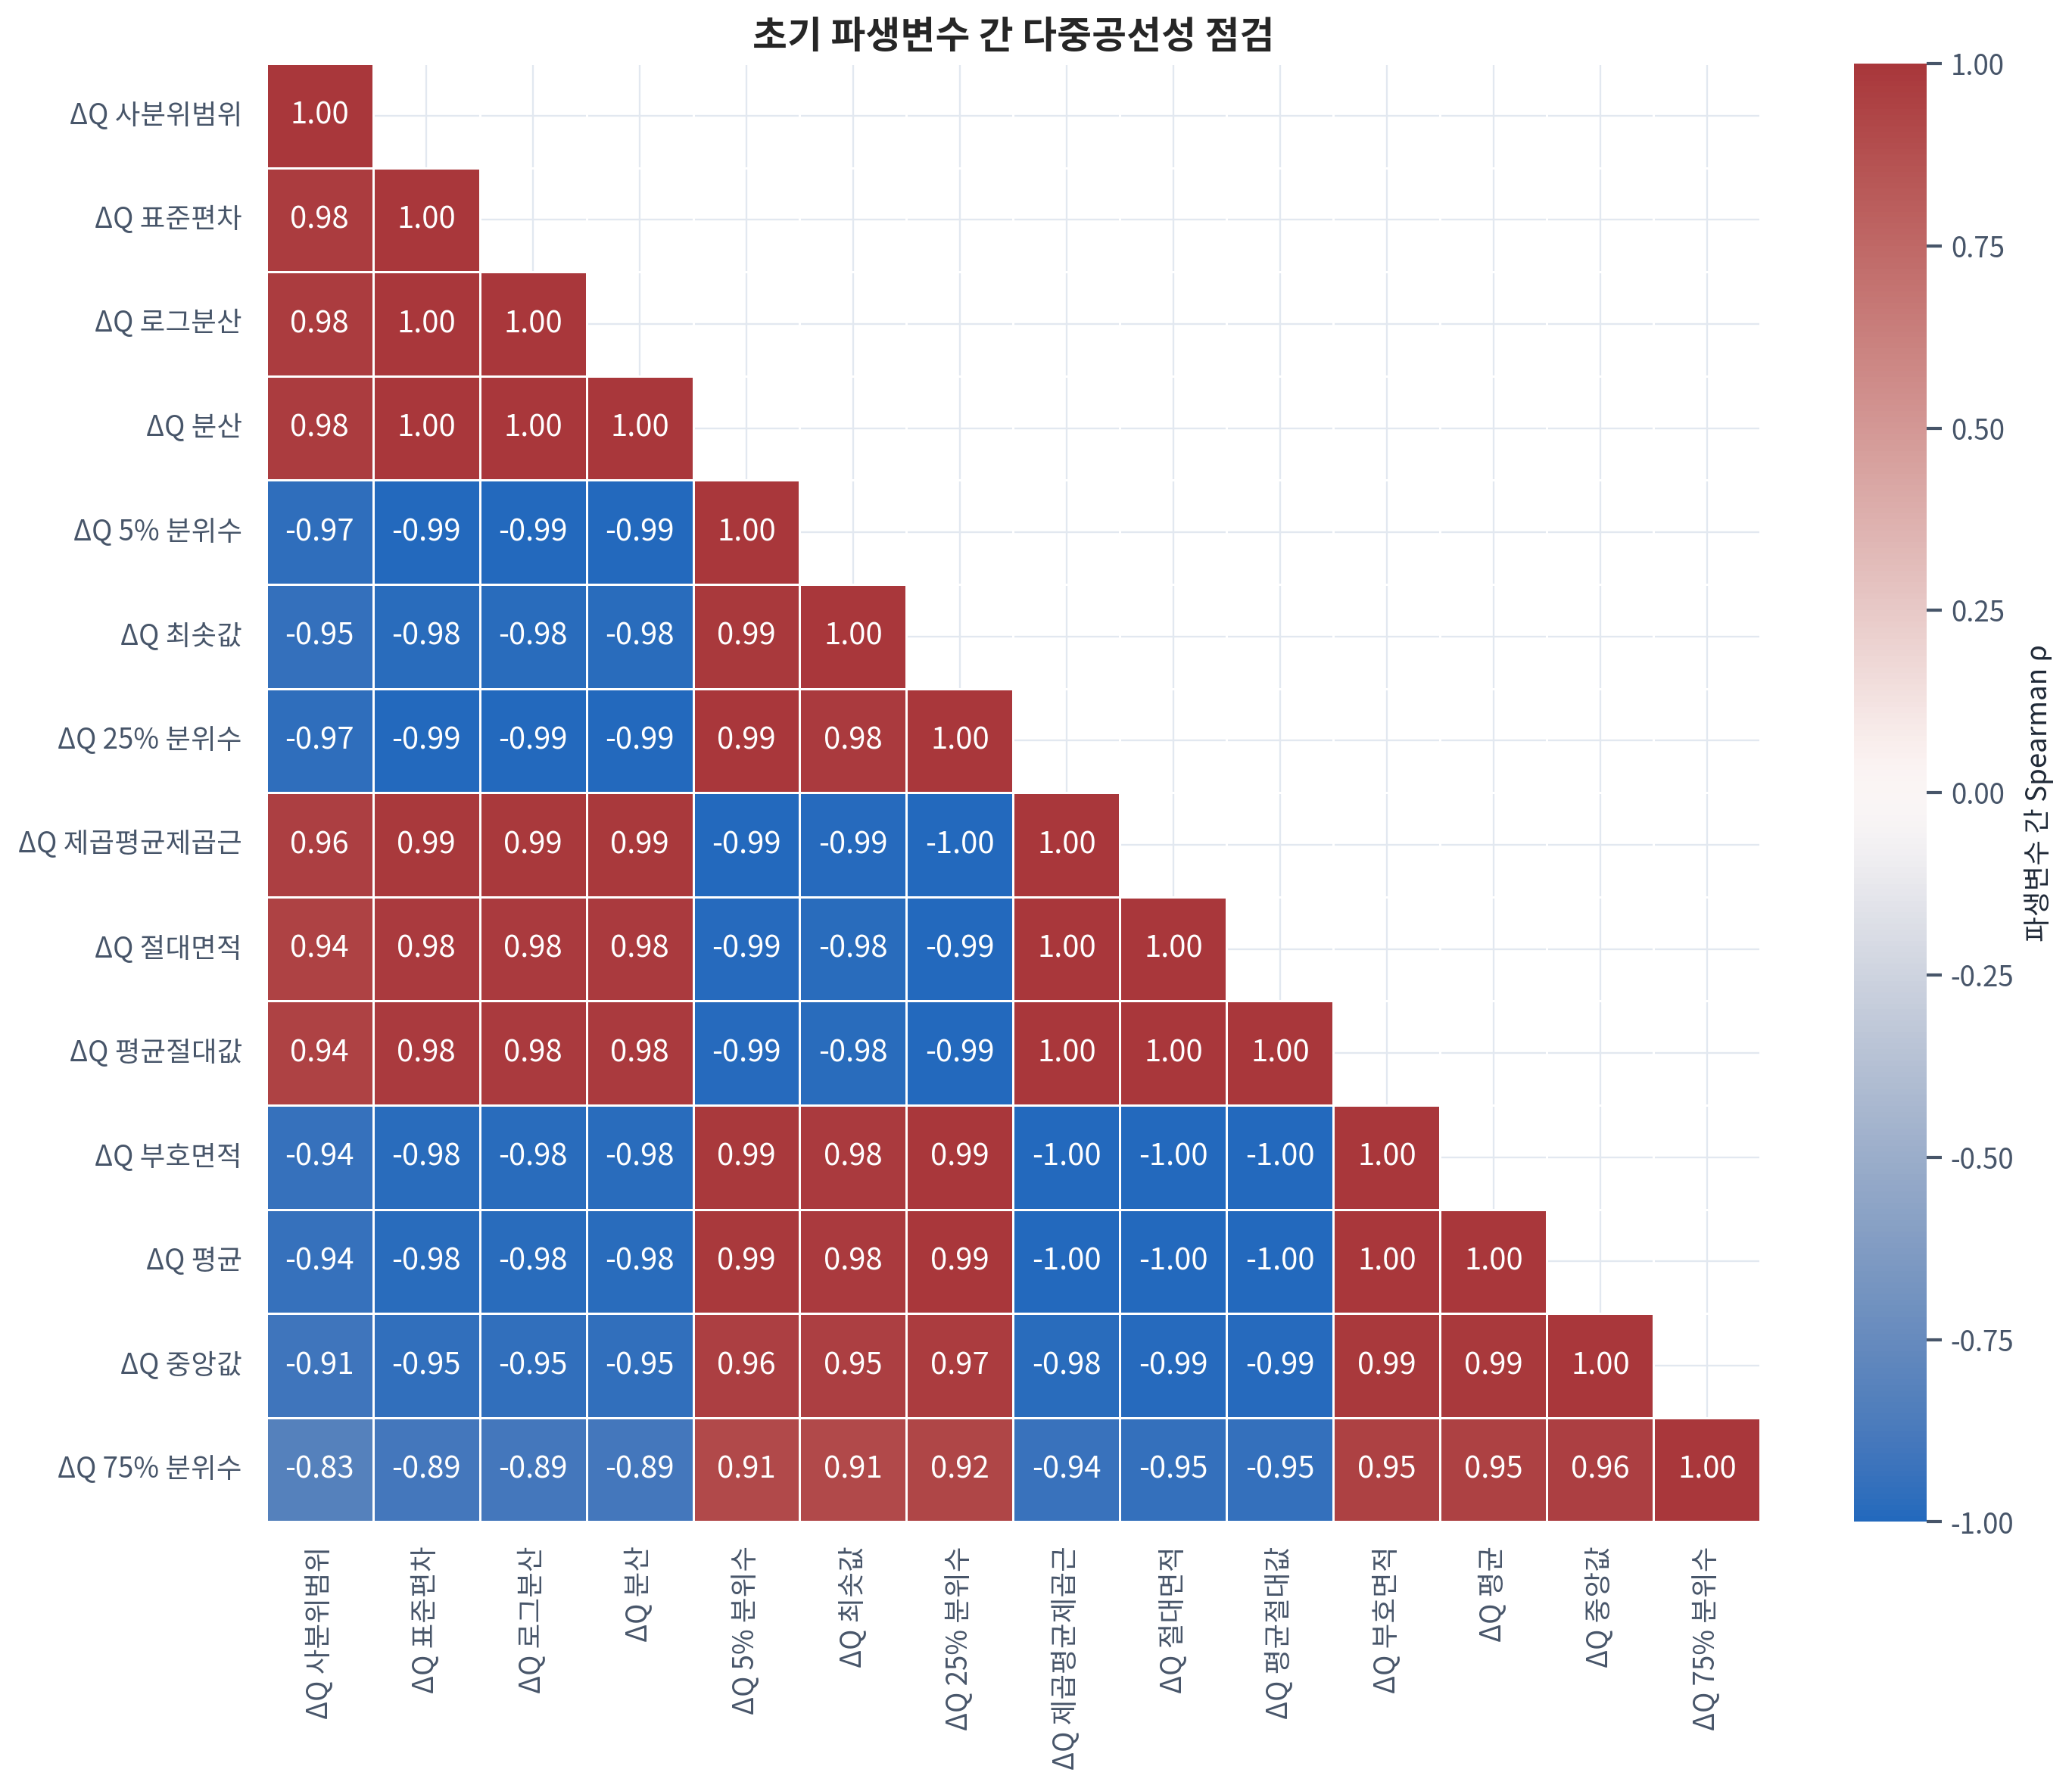

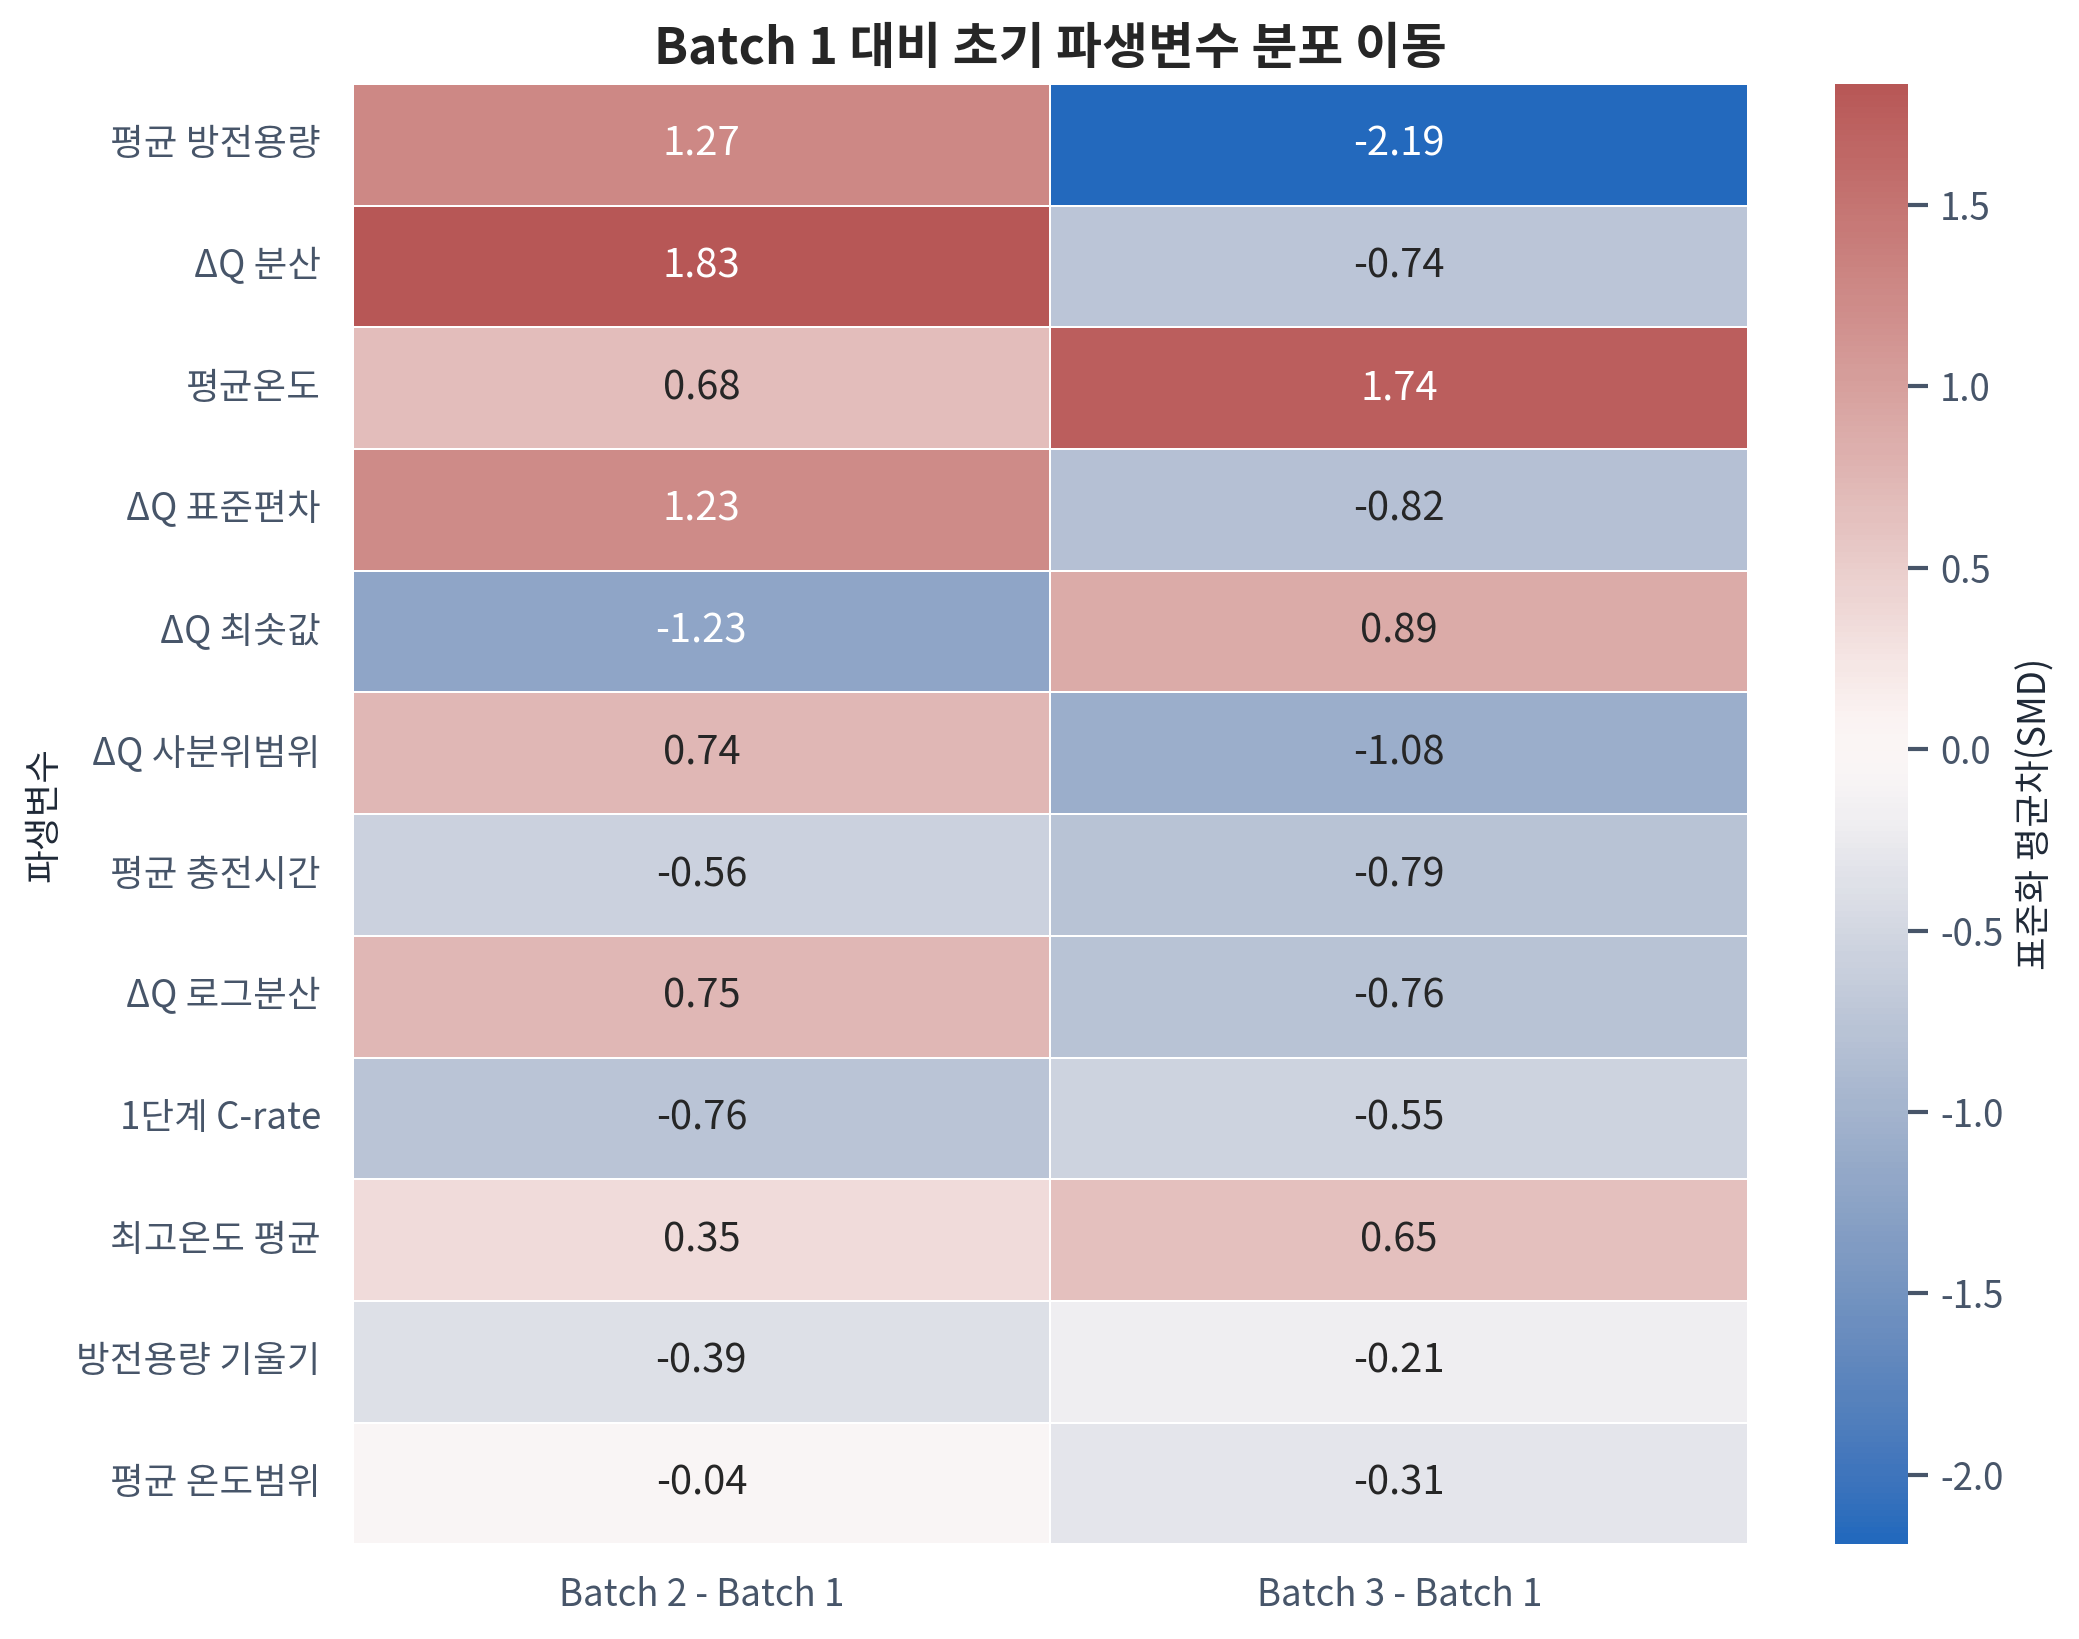

In [8]:
correlations = pd.read_csv(RESULT_DIR / 'correlation_results.csv')
display(correlations[correlations['scope'] == 'Batch 1'].sort_values('abs_spearman', ascending=False).head(20))
display(pd.read_csv(RESULT_DIR / 'feature_decisions.csv'))
display(Image(filename=str(FIGURE_DIR / '09_초기_신호_상관.png')))
display(Image(filename=str(FIGURE_DIR / '10_다중공선성.png')))
display(Image(filename=str(FIGURE_DIR / '11_배치_시프트.png')))

## 결론

최종 해석과 Day 2 전략은 `reports/DAY1_분석_보고서.md`에 정리되어 있습니다. 핵심 모델 후보는 Batch 1 내부 CV에서 비교할 Ridge/ElasticNet과 Gradient Boosting 계열이며, Batch 2는 최종 외부 테스트에만 사용합니다.